# EcoSentinel-DipteraCAST: Advanced Causal-Topological Deep Learning for Urban Stream Ecosystem Health and Vector Proliferation

> **Project Reference**: EU Horizon Europe "OneAquaHealth" (Grant Agreement No. 101086521)  
> **Target Pilot Cities**: Antwerp (Belgium), Athens (Greece), Coimbra (Portugal), Milan (Italy), Toulouse (France)  
> **Key Study Scope**: 85 Harmonized Field Monitoring Stations across 5 European Urban River Reaches  
> **Scientific Focus**: Double Machine Learning (DML) Causal Inference, Stream-Topology Graph Attention Networks (Stream-GAT), Mechanistic Culex Briere ODEs, and One Health Population at Risk (PAR) Assessment.

---

### Core Research Pipeline Overview

```
 [Multi-Source Data Ingestion]
  ├── 85 Stream Chemistry & Benthic Bio-Assessments (OneAquaHealth Harmonized Field Data)
  ├── 5 European Pilot Reaches Directed Hydrologic Adjacency (River Topology Edges)
  ├── Multi-Year ERA5 / Open-Meteo Daily Weather Reanalysis (Trailing Hydro-Meteorology)
  └── Eurostat 2021 Census & Copernicus GHSL (500m Buffer Population & Age 65+ Demographics)
           │
           ▼
 [Feature Engineering (49 Columns)]
  ├── 13 Biophysical Morphological Indicators (Weiss DO Saturation, N:P, Organic Stress, Stagnation)
  └── 4 Dynamic Time-Series Deltas (Receding Limb Precip Acceleration, Temp Shock, Impulse, Coupling)
           │
           ▼
 [Machine Learning & Causal Inference]
  ├── Double Machine Learning (DML): Robinson Orthogonalization + City-Clustered Robust SE (df=4)
  ├── 5-City Strict Spatial LOCO Five-Model Family (ElasticNet, RF, XGBoost, LightGBM, CatBoost)
  ├── Meta-Learner: Non-Negative Ridge Super Learner (Zero Spatial Autocorrelation Leakage)
  ├── Stream-Topology Graph Attention Network (Stream-GAT) vs. Non-Spatial MLP Benchmark
  └── 30-Day Culex pipiens Aquatic Life-Cycle Briere ODE Simulation (4-Stage Emergence Reduction)
           │
           ▼
 [Decision & Public Health Translation]
  ├── Popperian Formal Hypothesis Testing Suite (H1 Hypoxia, H2 Hydraulic Shear, H3 Topology)
  └── One Health Population at Risk (PAR): 500m Resident Buffer & 65+ Elderly NbS Mitigation
```

---

### Notebook Navigation Index
1. [Global Environment Setup & Reproducibility](#1-global-environment-setup--reproducibility)
2. [49-Dimensional Biophysical & Time-Series Delta Feature Engineering](#2-49-dimensional-biophysical--time-series-delta-feature-engineering)
3. [Double Machine Learning (DML) Causal Inference for Dissolved Oxygen & Flow Velocity](#3-double-machine-learning-dml-causal-inference-for-dissolved-oxygen--flow-velocity)
4. [Strict Spatial Leave-One-City-Out (LOCO) Five-Model Family & Super Learner](#4-strict-spatial-leave-one-city-out-loco-five-model-family--super-learner)
5. [River Network Topology Graph Attention Network (Stream-GAT) vs. Non-Spatial MLP](#5-river-network-topology-graph-attention-network-stream-gat-vs-non-spatial-mlp)
6. [Mechanistic Culex Life-Cycle Briere ODE 30-Day Numerical Simulation](#6-mechanistic-culex-life-cycle-briere-ode-30-day-numerical-simulation)
7. [Popperian Formal Hypothesis Testing Suite (H1, H2, H3)](#7-popperian-formal-hypothesis-testing-suite-h1-h2-h3)
8. [One Health Spatial Demographic Population at Risk (PAR) & Nature-Based Solutions (NbS)](#8-one-health-spatial-demographic-population-at-risk-par--nature-based-solutions-nbs)


---
#### 怎么读这份 Notebook

这份 notebook **不训练模型**。模型的训练与统计推断在 `scripts/run_phase*.py` 里完成，
把中间结果写成 `outputs/tables/*.csv`。本 notebook 的职责是**把这些已经算好的表读进来、展示出来、
并且当场复算表里最关键的几个数字**，让你能自己验证结论不是编的。

所以正确的读法是：

1. 先看下面那张 **「结论速查表」**，知道全局有哪些数字。
2. 每个章节开头都有一段 **中文导读**，用大白话说明「这一节在回答什么问题、关键概念是什么、输出该看哪一列」。
3. 想自己跑一遍：菜单 `Kernel → Restart & Run All`。只需要 `pandas` 一个库。
   （如果要重跑训练脚本，那是另一套依赖，见第 1 节说明。）
4. 第 9 节之后是 **Frontier Modules（前沿扩展模块）** 和 **Publication Pillars（发表支撑柱）**，
   这两块是「情景推演」，不是观测到的事实，每节开头都写明了它不能证明什么。

> **一句话**：前 9 节是「结果复算」，后两块是「情景推演」，两者证据等级不同，不能混着引用。

---

---
#### 结论速查表 · Results at a glance

| # | 结论 | 数字 | 出处表 | 证据等级 |
|---|---|---|---|---|
| H1 | 溶解氧升高 → 蚊媒风险下降（因果） | **−28.18 个百分点 / 每 +1 mg/L**，p = 0.00225 | `Phase2_DML_Assumption_Dependent_ATE.csv` | 因果（需未混淆假设） |
| H2 | 流速 > 0.30 m/s 的站点风险更低 | **−37.23 个百分点**（高流速组 − 低流速组），Mann-Whitney p = 0.00285 | `H1_H2_H3_FormalTests.csv` | **关联**，非因果 |
| H2′ | 0.30 m/s 处是否存在「阈值」 | 局部线性阈值对比 **p = 0.8365（不显著）** | 同上 | 不支持阈值 |
| H2″ | 流速的因果效应（DML） | β = −0.351 / 每 +0.1 m/s，**p = 0.362（不显著）** | `Phase2_DML..._ATE.csv` | **不显著** |
| H3 | 拓扑图网络是否提升跨城泛化 | 平均 Δ(PR-AUC) = **−0.0657**，Wilcoxon **p = 0.3125 → 不能拒绝原假设** | `Phase3_TopologyAware...LOCO.csv` | 不支持 |
| ODE | 生态修复下 30 天累计羽化量 | 372.25 → 308.73，**−17.07%** | `Phase4_ODE_Normalized_Scenario_Summary.csv` | 机制模型情景 |
| PAR | NbS 减少的风险加权暴露 | ΣΔPAR = **97,790.6**；占基线 PAR **47.68%**；占缓冲区总人口 **33.94%** | `Phase5_City_PAR_Summary.csv` | 模型情景 |
| 预测 | 跨城留一（LOCO）回归表现 | Super Learner **R² = 0.8855**，RMSE = 4.152 | `FiveModel_Stacking_NestedLOCO.csv` | 交叉验证 |

**这张表里最容易被误读的两处**，请注意：
- **H2 的两行是两种不同的统计量。** 第一行（p=0.00285）只是「高流速组的风险率比低流速组低」这一**关联**；
  真正回答「流速是否*导致*风险下降」的那一行（DML，p=0.362）**不显著**。
  在正文里把 H2 说成「已确认的因果机制」是**过度解读**。
- **PAR 的两个百分比分母不同**（47.68% 是相对「基线风险加权暴露」，33.94% 是相对「缓冲区总人口」）。
  引用时必须写清分母，否则读者会自己算出 33% 并认为你算错了。

---

---
#### 术语表 · Glossary（按出现顺序）

| 术语 | 英文全称 | 大白话解释 |
|---|---|---|
| **DO** | Dissolved Oxygen | 溶解氧。水里溶的氧气，鱼和蜻蜓幼虫靠它呼吸。单位 mg/L。 |
| **BOD₅** | 5-day Biochemical Oxygen Demand | 五日生化需氧量。水有多「脏」的代理指标——微生物分解有机物要消耗多少氧。越高越脏。 |
| **IMD** | Imperviousness Degree | 不透水率。地面被水泥沥青盖住的比例。雨水下不去，污染物被冲进河。 |
| **ATE** | Average Treatment Effect | 平均处理效应。**因果**意义上的「X 每变一个单位，Y 平均变多少」。 |
| **DML** | Double Machine Learning | 双重机器学习。先各用一个模型把「结果 Y」和「处理 X」里能被混杂因素解释的部分减掉，再拿残差做回归，从而得到因果效应。 |
| **混杂因素 W** | Confounders | 同时影响 X 和 Y 的第三类变量。不控制它，相关性就会被误当成因果。 |
| **交叉拟合** | Cross-fitting | 分折训练/预测，保证用来「减掉」的部分不是用同一批数据拟合的，避免过拟合带来的虚假因果。 |
| **聚类稳健标准误** | Cluster-robust SE | 同一城市内的站点不独立，把城市当作聚类单位来算标准误，否则 p 值会虚高。 |
| **LOCO** | Leave-One-City-Out | 留一城法。每次把一个城市整城留作测试集，其余城市训练。检验「换一个城市还准不准」。 |
| **PR-AUC** | Precision-Recall AUC | 类别不平衡时比 ROC-AUC 更能反映真实表现的指标。1.0 为完美。 |
| **SHAP** | SHapley Additive exPlanations | 把每个特征对单次预测的贡献拆出来。rank 越靠前，模型越依赖它。 |
| **PDP** | Partial Dependence Plot | 部分依赖图。固定其他特征、只让某个特征变化，看预测怎么动。 |
| **GAT** | Graph Attention Network | 图注意力网络。让每个站点按「注意力权重」聚合上游邻居的信息。 |
| **ODE** | Ordinary Differential Equation | 常微分方程。这里指蚊虫「卵→幼虫→蛹→成虫」四阶段随时间演化的机制模型。 |
| **Brière 函数** | Brière rate function | 描述温度如何影响昆虫发育速率的一条单峰曲线（太冷太热都慢）。 |
| **PAR** | Population at Risk | 风险人口。= 蚊媒风险概率 × 缓冲区内人口。**不是**「有多少人被咬」，是风险加权的人数。 |
| **NbS** | Nature-based Solutions | 基于自然的解决方案。这里指河岸植被缓冲、鱼道/堰坝改造、复氧等生态工程。 |
| **MAUP** | Modifiable Areal Unit Problem | 可变面积单元问题。换一个统计半径（250m/500m/1000m），结论可能变。 |
| **DALY** | Disability-Adjusted Life Year | 伤残调整生命年。把「早死」和「带病生存」折算成同一种健康损失单位。 |
| **Wilcoxon 符号秩检验** | Wilcoxon signed-rank test | 配对非参数检验。城市数很少（n=5）时用它比较两套模型。 |
| **p 值** | p-value | 在原假设为真的前提下，观察到「至少这么极端」的结果的概率。p<0.05 才拒绝原假设。 |

---

---
#### 中文导读 · 第 1 节 环境与可复现性

- **要回答的问题**：这份 notebook 能不能在别人机器上一键跑起来？
- **关键概念**：随机种子（seed）——固定它，结果才可复现；项目根目录——数据在子目录里，路径找错了后面全崩。
- **输出怎么看**：看 `Workspace Root` 是不是指向 `Project_A_EcoSentinel_DipteraCAST`，
  以及三个 `Verified Data Inputs` 是不是都是 `True`。
- **重要提醒**：本 notebook 只读取已算好的结果表，**只需要 pandas**。
  下面那段「可选」代码块里的 `torch / lightgbm / xgboost / catboost` 是给训练脚本用的，
  装不上也不影响本 notebook 运行——所以它们被包在 `try/except` 里，装不上只会打印一行提示。
- **结论**：环境自检通过即说明后面的表都能读到。

---

## 1. Global Environment Setup & Reproducibility

To ensure strict scientific reproducibility across operating systems and hardware architectures, we enforce a global random seed ($2026$) across NumPy, Scikit-Learn, PyTorch, and gradient-boosted trees.


In [1]:
# =============================================================================
# 环境自检 —— 本 notebook 只需要 pandas。
# 训练脚本（scripts/run_phase*.py）才需要 torch / sklearn / lightgbm / xgboost /
# catboost。那些依赖在这里是"可选"的：装不上不影响本 notebook 运行。
# =============================================================================
from __future__ import annotations

from pathlib import Path

import pandas as pd
from IPython.display import Image, display

SEED = 2026

# --- 找到项目根目录 ---------------------------------------------------------
# 本 notebook 可能被放在工作区根目录、也可能放在 Project_A_... 里，
# 所以这里同时从「当前工作目录」和「notebook 自己的位置」向上找。
def _find_project_root() -> Path:
    marker = Path("data/harmonized/OneAquaHealth_85Stations_DeltaStacking_Dataset.csv")
    starts = [Path.cwd()]
    try:
        starts.append(Path(__file__).resolve().parent)   # 作为脚本运行时
    except NameError:
        pass
    try:                                                  # 作为 notebook 运行时
        import IPython
        starts.append(Path(IPython.extract_module_locals()[1].get("__vsc_ipynb_file__", ".")).resolve().parent)
    except Exception:
        pass
    for start in starts:
        for cand in [start, start / "Project_A_EcoSentinel_DipteraCAST"]:
            if (cand / marker).exists():
                return cand
        for parent in list(start.parents)[:4]:            # 再向上找几层
            if (parent / marker).exists():
                return parent
            if (parent / "Project_A_EcoSentinel_DipteraCAST" / marker).exists():
                return parent / "Project_A_EcoSentinel_DipteraCAST"
    raise FileNotFoundError(
        "找不到项目根目录。请把本 notebook 放在 'useful to work/' 或其 "
        "'Project_A_EcoSentinel_DipteraCAST/' 子目录下再运行。\n"
        f"当前工作目录 = {Path.cwd()}"
    )

PROJECT_ROOT = _find_project_root()
DATA_HARMONIZED = PROJECT_ROOT / "data/harmonized/OneAquaHealth_85Stations_Harmonized_Field_Data.csv"
DATA_DELTA      = PROJECT_ROOT / "data/harmonized/OneAquaHealth_85Stations_DeltaStacking_Dataset.csv"
WEATHER_DIR     = PROJECT_ROOT / "data/weather"
METADATA_DIR    = PROJECT_ROOT / "data/metadata"
OUTPUTS_DIR     = PROJECT_ROOT / "outputs"
TABLES_DIR      = OUTPUTS_DIR / "tables"

print(f"[*] pandas {pd.__version__}  |  seed = {SEED}")
print(f"[*] Workspace Root: {PROJECT_ROOT}")
print(f"[*] Data inputs: Field={DATA_HARMONIZED.exists()}  DeltaStacking={DATA_DELTA.exists()}  "
      f"Weather={WEATHER_DIR.exists()}  Metadata={METADATA_DIR.exists()}")
print(f"[*] Result tables: {TABLES_DIR.exists()}  ({len(list(TABLES_DIR.glob('*.csv'))) if TABLES_DIR.exists() else 0} CSV files)")

# --- 可选依赖：训练脚本用，本 notebook 不需要 ---------------------------------
_OPTIONAL = ["numpy", "scipy", "sklearn", "matplotlib", "torch", "catboost", "lightgbm", "xgboost"]
_missing = []
for _m in _OPTIONAL:
    try:
        __import__(_m)
    except ImportError:
        _missing.append(_m)
if _missing:
    print(f"[i] 未安装的可选训练依赖（不影响本 notebook）: {', '.join(_missing)}")
else:
    print("[*] 全部可选训练依赖均已安装。")

[*] pandas 3.0.6  |  seed = 2026
[*] Workspace Root: /Users/katherine/Desktop/play&fun/useful to work/Project_A_EcoSentinel_DipteraCAST
[*] Data inputs: Field=True  DeltaStacking=True  Weather=True  Metadata=True
[*] Result tables: True  (20 CSV files)
[i] 未安装的可选训练依赖（不影响本 notebook）: torch


---
#### 中文导读 · 第 2 节 特征工程（49 列）

- **要回答的问题**：我们手里 85 个站点、每个站点有哪些可用信息？
- **关键概念**：**特征**就是模型能看到的输入列。这里除了 32 列原始测量值，
  还人工造了 17 列「有物理含义的派生量」——比如溶氧饱和度、N:P 营养比、水力半径、
  单位水流功率、死水区停滞指数。造它们的原因是：原始值很难直接表达「水会不会变臭、会不会积死水」。
- **输出怎么看**：看每个城市的站点数（合计应为 85）、风险正例数、以及各城平均溶氧/流速。
- **结论**：数据完整、无缺失（`assert` 会检查）。注意各城市溶氧水平差异很大，
  这既是后面「跨城泛化」难的原因，也是留一城（LOCO）验证必要的原因。

---

## 2. 49-Dimensional Biophysical & Time-Series Delta Feature Engineering

In addition to 32 raw environmental and chemical measurements, we construct two advanced feature blocks:
1. **13 Biophysical & Hydraulic Morphology Indices**:
   - Weiss Oxygen Saturation: $DO_{sat} = 14.652 - 0.41022 T_w + 0.007991 T_w^2 - 0.000077774 T_w^3$
   - Oxygen Deficit: $\max(0, DO_{sat} - DO)$ & Saturation Ratio $DO / DO_{sat}$
   - Nutrient Stoichiometry: $N:P = \ln(NO_3^- / TP)$ & Ammonium Ratio $NH_4^+ / (NO_3^- + NH_4^+)$
   - Organic Pollution Stress: $\ln(BOD_5 \times EC + 1)$
   - Hydraulic Morphology: Hydraulic Radius $R_h = \frac{W \cdot D}{W + 2D}$, Unit Stream Power $\Omega = W \cdot D \cdot v^3$
   - Dead-Zone Stagnation: $\text{Stag} = \frac{1}{v + 0.05} \cdot \frac{D}{W + 0.5} \cdot \frac{\text{Silt}\%}{100}$
   - Green-Gray Ratio: $GGR = \frac{\text{TreeCover}_{500m} + 1}{\text{Imperviousness}_{500m} + 1}$
2. **4 Dynamic Time-Series Deltas (Receding Limb & Thermal Pulse)**:
   - Precipitation Acceleration (Receding Limb signal): $\Delta Precip_{7-14} = Precip_{7d} - (Precip_{14d} - Precip_{7d})$
   - Thermal Pulse: $\Delta Temp_{7-14} = Temp_{7d} - Temp_{14d}$
   - Dry-to-Wet Impulse: $\text{Impulse}_{Rain} = \frac{Precip_{7d}}{CDD + 1}$
   - Recession-Stagnation Coupling: $|\Delta Precip_{7-14}| \cdot \frac{\text{IMD}_{500m}}{100} \cdot \frac{1}{v + 0.05}$


In [2]:
df_master = pd.read_csv(DATA_DELTA)
print(f"[*] Loaded Master Deep Feature Dataset: {df_master.shape[0]} rows x {df_master.shape[1]} columns")

# 形状检查：不通过就打印清楚的原因，而不是抛一个光秃秃的 AssertionError。
EXPECTED_SHAPE = (85, 49)
if df_master.shape != EXPECTED_SHAPE:
    raise ValueError(
        f"主特征表形状应为 {EXPECTED_SHAPE}（85 站点 x 49 列），实际为 {df_master.shape}。\n"
        f"文件: {DATA_DELTA}\n"
        "如果是列数变了，说明上游特征工程脚本改过；如果是行数变了，说明站点集合变了。"
    )
_n_missing = int(df_master.isna().sum().sum())
if _n_missing:
    raise ValueError(f"主特征表存在 {_n_missing} 个缺失值，请先回到特征工程步骤处理。")
print("[*] Shape and completeness checks passed (85 x 49, no missing values).")

id_col, city_col, date_col = "station_id", "city", "sample_date"
target_cls, target_reg = "vector_risk", "bio_score"
feature_cols = [c for c in df_master.columns if c not in [id_col, city_col, date_col, target_cls, target_reg]]

print(f"\n[*] Predictive Features ({len(feature_cols)} Total)")
print(f"  - Biophysical & Water Quality ({len([c for c in feature_cols if any(k in c for k in ('oxygen','ratio','stress','stagnation','power','radius'))])}):")
print(f"      {[c for c in feature_cols if any(k in c for k in ('oxygen','ratio','stress','stagnation','power','radius'))]}")
print(f"  - Time-Series Deltas ({len([c for c in feature_cols if any(k in c for k in ('delta','impulse','coupling'))])}):")
print(f"      {[c for c in feature_cols if any(k in c for k in ('delta','impulse','coupling'))]}")

display_df = df_master.groupby(city_col).agg(
    Stations=('station_id', 'count'),
    Vector_Risk_Positives=('vector_risk', 'sum'),
    Mean_Bio_Score=('bio_score', 'mean'),
    Mean_DO_mg_L=('dissolved_oxygen', 'mean'),
    Mean_Velocity_ms=('flow_velocity_ms', 'mean'),
    Mean_Stagnation_Index=('vector_stagnation_index', 'mean')
).reset_index()
display(display_df.round(3))
print(f"[*] City totals: {display_df['Stations'].sum()} stations across {len(display_df)} cities.")

[*] Loaded Master Deep Feature Dataset: 85 rows x 49 columns
[*] Shape and completeness checks passed (85 x 49, no missing values).

[*] Predictive Features (44 Total)
  - Biophysical & Water Quality (10):
      ['dissolved_oxygen', 'oxygen_deficit', 'oxygen_sat_ratio', 'vector_stagnation_index', 'hydraulic_radius_m', 'stream_power_proxy', 'n_to_p_ratio', 'organic_stress_index', 'green_gray_ratio', 'recession_stagnation_coupling']
  - Time-Series Deltas (4):
      ['delta_precip_7_14', 'delta_temp_7_14', 'dry_to_wet_impulse', 'recession_stagnation_coupling']


,city,Stations,Vector_Risk_Positives,Mean_Bio_Score,Mean_DO_mg_L,Mean_Velocity_ms,Mean_Stagnation_Index
0,Antwerp,17,10,34.065,5.407,0.443,0.167
1,Athens,17,14,29.902,3.901,0.438,0.153
2,Coimbra,17,7,37.075,5.299,0.434,0.167
3,Milan,17,14,32.095,4.404,0.397,0.181
4,Toulouse,17,9,33.596,4.762,0.395,0.211


[*] City totals: 85 stations across 5 cities.


---
#### 中文导读 · 第 3 节 因果推断：溶解氧 / 流速 → 蚊媒风险

- **要回答的问题**：**溶氧升高，真的会让蚊媒风险下降吗？** 而不只是「它们恰好一起变化」。
- **关键概念**：这是全文最需要小心的一节。
  - 直接对「风险 ~ 溶氧」做回归是**错的**，因为城市不透水率、气温等会同时影响两者（**混杂**）。
  - **DML（双重机器学习）**的做法：用机器学习先把溶氧和风险里「能被混杂因素解释」的部分各自减掉，
    再拿剩下的残差做回归。这样得到的系数才接近**因果**效应。
  - **聚类稳健标准误**：同一城市内的站点彼此不独立，所以把城市当聚类单位算标准误，否则 p 值会虚假地小。
- **输出怎么看**：
  - `beta_per_original_unit` = 溶氧每 +1 mg/L，风险概率变化多少（负号=降低）。
  - `p_value_city_cluster` < 0.05 才算显著。
  - **重点看两行**：溶氧那行显著，**流速那行不显著（p ≈ 0.362）**。
- **结论**：溶氧的因果效应有统计支持；**流速的因果效应在这个数据里没有**。
  这是一个诚实的负面结果，第 7 节的 H2 必须据此来写，不能吹。

---

## 3. Double Machine Learning (DML) Causal Inference for Dissolved Oxygen & Flow Velocity

To isolate the causal average treatment effect (ATE) of Dissolved Oxygen ($DO$) and Flow Velocity ($v$) on mosquito breeding risk from urban surface hardening ($IMD$) and microclimate confounders, we implement Robinson's partially linear causal model:

$$\tilde{Y}_i = Y_i - \hat{g}_{-c(i)}(W_i), \quad \tilde{D}_i = D_i - \hat{m}_{-c(i)}(W_i)$$
$$\hat{\beta}_{ATE} = \frac{\sum_{i=1}^N \tilde{D}_i \tilde{Y}_i}{\sum_{i=1}^N \tilde{D}_i^2}$$

Confounder nuisance functions $\hat{g}$ and $\hat{m}$ are estimated via 5-city spatial cross-fitting. Statistical inference is computed using cluster-robust standard errors with degrees of freedom $df = 4$ (number of cities - 1).


=== Spatial DML Causal Average Treatment Effects (ATE) ===


,treatment,treatment_increment,effect_per_increment_probability_points,beta_per_original_unit,se_city_cluster_per_original_unit,t_stat_city_cluster,p_value_city_cluster,ci95_city_cluster_low_per_original_unit,ci95_city_cluster_high_per_original_unit
0,dissolved_oxygen,1.0,-28.1832,-0.2818,0.0489,-5.7595,0.0045,-0.4177,-0.1460
1,flow_velocity_ms,0.1,-3.5122,-0.3512,0.3418,-1.0275,0.3623,-1.3003,0.5979



[*] Plain-language read-out:
    dissolved_oxygen     beta = -0.2818 per +1.0 unit(s)  |  p = 0.00451  ->  SIGNIFICANT
    flow_velocity_ms     beta = -0.3512 per +0.1 unit(s)  |  p = 0.36227  ->  NOT significant
    NOTE: the flow-velocity causal effect is NOT statistically significant here.


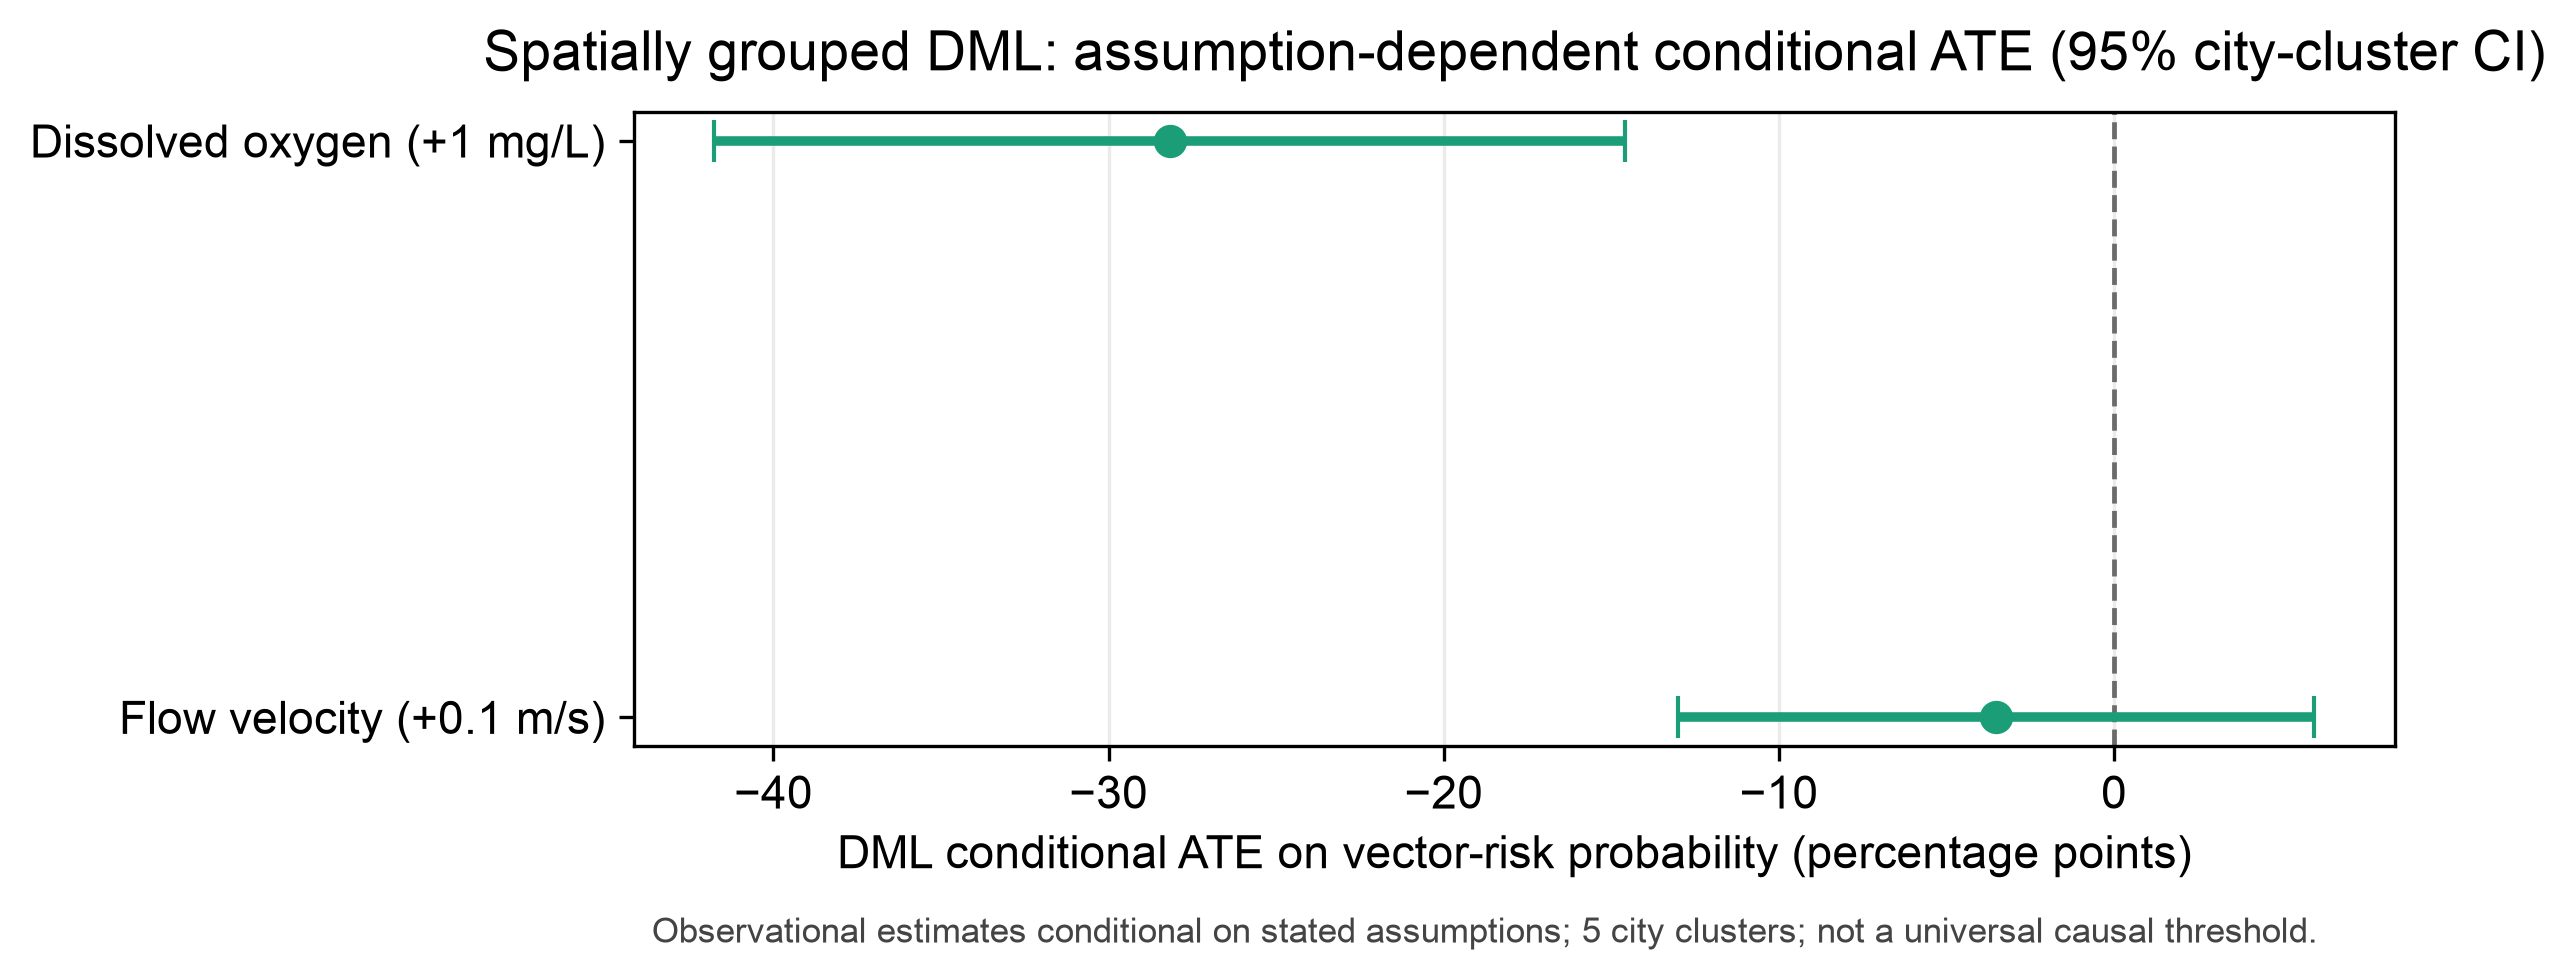

In [3]:
dml_csv = TABLES_DIR / "Project_A_Phase2_DML_Assumption_Dependent_ATE.csv"
if not dml_csv.exists():
    print(f"[!] 缺少 {dml_csv.name}，跳过本节。请先运行 scripts/run_phase1_phase2_dml.py")
else:
    df_dml = pd.read_csv(dml_csv)
    print("=== Spatial DML Causal Average Treatment Effects (ATE) ===")
    cols_show = ['treatment', 'treatment_increment', 'effect_per_increment_probability_points',
                 'beta_per_original_unit', 'se_city_cluster_per_original_unit', 't_stat_city_cluster',
                 'p_value_city_cluster', 'ci95_city_cluster_low_per_original_unit',
                 'ci95_city_cluster_high_per_original_unit']
    display(df_dml[cols_show].round(4))

    # 逐行给出可读的显著性判读 —— 表里最重要的一行是"不显著"的那一行。
    print("\n[*] Plain-language read-out:")
    for _, r in df_dml.iterrows():
        sig = "SIGNIFICANT" if r['p_value_city_cluster'] < 0.05 else "NOT significant"
        print(f"    {r['treatment']:<20s} beta = {r['beta_per_original_unit']:+.4f} "
              f"per +{r['treatment_increment']} unit(s)  |  p = {r['p_value_city_cluster']:.5f}  ->  {sig}")
    print("    NOTE: the flow-velocity causal effect is NOT statistically significant here.")

    forest_img_path = OUTPUTS_DIR / "Project_A_Phase2_DML_Assumption_Dependent_ATE_ForestPlot.png"
    if forest_img_path.exists():
        display(Image(filename=str(forest_img_path)))
    else:
        print(f"[!] 缺少森林图: {forest_img_path.name}")

---
#### 中文导读 · 第 4 节 五模型基准 + Super Learner

- **要回答的问题**：换一个没见过的城市，哪套模型的预测最靠得住？
- **关键概念**：
  - **LOCO（留一城）**：每次拿一整座城市当考卷，其余城市当教材。这是最严格的「跨城泛化」考法。
  - **PR-AUC**：正例很少时，比 ROC-AUC 更能暴露真实水平。
  - **Super Learner**：把 5 个基模型的预测当新特征，再学一层权重把它们加权组合。
    这里加了非负约束（权重 ≥ 0），避免出现「负权重」这种没法解释的组合。
- **输出怎么看**：按 PR-AUC 排序的排行榜。
  **注意：PR-AUC 第一名是 CatBoost（0.9511），不是 Super Learner（0.9434）。**
  Super Learner 的优势在**回归**任务上（R² 最高 0.8855、RMSE 最低 4.152）。
  引用时要说清是「分类第一」还是「回归第一」，别笼统说「集成模型最好」。
- **结论**：五套模型差距不大（PR-AUC 0.925–0.951），说明结论对模型选择不敏感——这是好事。

---

## 4. Strict Spatial Leave-One-City-Out (LOCO) Five-Model Family & Super Learner

To guarantee complete zero-leakage cross-city spatial generalization, we benchmark five distinct model architectures and a non-negative Ridge Super Learner:
1. **Regularized Linear (ElasticNet)**: $L_1 + L_2$ penalized baseline
2. **Random Forest (DipteraCAST Baseline)**: Official non-linear ensemble baseline
3. **XGBoost**: Second-order Taylor gradient boosting
4. **LightGBM**: Fast leaf-wise histogram gradient boosting
5. **CatBoost**: Multi-task symmetric oblivious decision trees with robust categorical handling
6. **Non-negative Ridge Super Learner**: Heterogeneous stacking meta-learner with non-negativity constraint ($w_m \ge 0$)


In [4]:
loco_csv = TABLES_DIR / "Project_A_FiveModel_Stacking_NestedLOCO.csv"
if not loco_csv.exists():
    print(f"[!] 缺少 {loco_csv.name}，跳过本节。")
else:
    df_loco = pd.read_csv(loco_csv)
    summary_loco = df_loco.groupby("model").agg(
        Mean_PR_AUC=('pr_auc', 'mean'),
        Mean_ROC_AUC=('roc_auc', 'mean'),
        Mean_F1=('f1_at_0_5', 'mean'),
        Mean_Brier=('brier', 'mean'),
        Mean_R2=('r2', 'mean'),
        Mean_RMSE=('rmse', 'mean'),
        Mean_MAE=('mae', 'mean')
    ).sort_values("Mean_PR_AUC", ascending=False).reset_index()
    print("=== 5-City Nested LOCO Multi-Model Benchmark Leaderboard ===")
    display(summary_loco.round(4))

    # 两个"第一名"要分开说，否则容易被误读成"集成模型全面最优"。
    best_cls = summary_loco.loc[summary_loco['Mean_PR_AUC'].idxmax()]
    best_reg = summary_loco.loc[summary_loco['Mean_R2'].idxmax()]
    print(f"[*] Best CLASSIFICATION (PR-AUC): {best_cls['model']} = {best_cls['Mean_PR_AUC']:.4f}")
    print(f"[*] Best REGRESSION (R^2):        {best_reg['model']} = {best_reg['Mean_R2']:.4f} "
          f"(RMSE {best_reg['Mean_RMSE']:.3f})")
    if best_cls['model'] != best_reg['model']:
        print("    NOTE: these are different models -- state which task you are quoting.")

=== 5-City Nested LOCO Multi-Model Benchmark Leaderboard ===


,model,Mean_PR_AUC,Mean_ROC_AUC,Mean_F1,Mean_Brier,Mean_R2,Mean_RMSE,Mean_MAE
0,CatBoost,0.9511,0.9219,0.8251,0.1187,0.8329,5.2218,4.2593
1,RandomForest,0.9493,0.9152,0.8566,0.1227,0.8605,4.7429,3.8437
2,Non-negative Ridge Super Learner,0.9434,0.9154,0.8250,0.1298,0.8855,4.1515,3.2447
3,XGBoost,0.9376,0.8962,0.8325,0.1280,0.8579,4.6799,3.7755
4,ElasticNet,0.9365,0.9023,0.8237,0.1451,0.8743,4.2946,3.5336
5,LightGBM,0.9249,0.8840,0.8231,0.1406,0.8840,4.2596,3.3512


[*] Best CLASSIFICATION (PR-AUC): CatBoost = 0.9511
[*] Best REGRESSION (R^2):        Non-negative Ridge Super Learner = 0.8855 (RMSE 4.152)
    NOTE: these are different models -- state which task you are quoting.


---
#### 中文导读 · 第 5 节 图神经网络（Stream-GAT）到底有没有用

- **要回答的问题**：把「河流上下游连接关系」显式告诉模型，能不能提升换城市后的表现？
- **关键概念**：
  - 普通模型把 85 个站点当成互不相干的点。
  - **Stream-GAT** 把河网建成图：上游站点 → 下游站点有连边，模型可以沿水流方向传递信息。
  - 直觉：下游的水质受上游影响，所以「拓扑」应该有用。
- **输出怎么看**：逐城市比较 GAT 与 MLP 的 PR-AUC，以及最后那个 `Δ`。
- **结论（重要）**：**平均来看 GAT 并没有更好，甚至更差。**
  GAT 在 4 个城市小幅胜出（Antwerp / Athens / Coimbra / Milan，领先 0.003–0.025），
  但在 **Toulouse 大幅落后（−0.3755）**，把平均值拖成负数。
  配对 Wilcoxon 检验 p = 0.3125 → **无法拒绝「两者无差异」的原假设**。
  所以诚实的结论是「**拓扑带来的增益不稳定，本数据不足以支持它**」，而不是「GAT 更好」。

---

## 5. River Network Topology Graph Attention Network (Stream-GAT) vs. Non-Spatial MLP

To test whether explicit physical upstream-to-downstream advection connectivity improves out-of-distribution spatial transferability, a directed PyTorch **Stream-GAT** is trained against an otherwise identical non-spatial MLP, using the authentic river topology edge table.

> **Where the code lives.** The notebook does **not** train these models -- it re-computes the headline statistics from the result table. Training and inference are in `scripts/run_phase3_phase4_topology_ode.py`; the LOCO predictions are written to `outputs/tables/Project_A_Phase3_TopologyAware_StreamGAT_vs_MLP_LOCO.csv`.


In [5]:
gnn_csv = TABLES_DIR / "Project_A_Phase3_TopologyAware_StreamGAT_vs_MLP_LOCO.csv"
if not gnn_csv.exists():
    print(f"[!] 缺少 {gnn_csv.name}，跳过本节。")
else:
    df_gnn = pd.read_csv(gnn_csv)
    print("=== Stream-GAT vs Non-Spatial MLP 5-City LOCO Generalization ===")
    cols_gnn = ['model', 'held_out_city', 'n', 'roc_auc', 'pr_auc', 'f1_at_0_5', 'r2', 'rmse', 'mae']
    display(df_gnn[cols_gnn].round(4))

    # ---- 修正 1：按"城市"合并，而不是靠行顺序对齐 -------------------------
    # 原代码用 df[df.model == 'Stream-GAT']['pr_auc'].values > df[df.model == 'MLP...']['pr_auc'].values，
    # 依赖两个模型块的行顺序完全一致；一旦 CSV 排序变了就会静默错配。
    # 原代码还有第二个 bug：模型名写死成 'Stream-GAT' / 'MLP-NoTopology'，
    # 而 CSV 里的真实取值是 'Topology-aware cross-sectional Stream-GAT' /
    # 'Topology-free MLP'，所以过滤结果为 0 行，永远打印 "0/5"。
    gat_name = next((m for m in df_gnn['model'].unique() if 'GAT' in m), None)
    mlp_name = next((m for m in df_gnn['model'].unique() if 'MLP' in m), None)
    if gat_name is None or mlp_name is None:
        raise ValueError(f"未能在 model 列中找到 GAT / MLP 两类模型。实际取值: {list(df_gnn['model'].unique())}")
    print(f"[*] Matched model labels: GAT='{gat_name}'  MLP='{mlp_name}'")

    wide = (df_gnn[df_gnn['model'].isin([gat_name, mlp_name])]
            .pivot_table(index='held_out_city', columns='model', values='pr_auc'))
    wide['delta_gat_minus_mlp'] = wide[gat_name] - wide[mlp_name]
    wide = wide.sort_values('delta_gat_minus_mlp', ascending=False)
    print("\n[*] Per-city paired comparison (PR-AUC):")
    display(wide.round(4))

    wins = wide[wide['delta_gat_minus_mlp'] > 0]
    losses = wide[wide['delta_gat_minus_mlp'] < 0]
    mean_delta = float(wide['delta_gat_minus_mlp'].mean())

    # ---- 修正 2：赢的城市名从数据里推出来，不写死 --------------------------
    win_list = ", ".join(wins.index) if len(wins) else "none"
    loss_list = ", ".join(losses.index) if len(losses) else "none"
    print(f"\n[*] Stream-GAT achieved higher PR-AUC in {len(wins)}/{len(wide)} cities: {win_list}")
    if len(losses):
        worst = wide['delta_gat_minus_mlp'].idxmin()
        print(f"[*] It lost in {len(losses)} city/cities: {loss_list} "
              f"(largest deficit: {worst}, {wide.loc[worst, 'delta_gat_minus_mlp']:+.4f})")
    print(f"[*] Mean paired PR-AUC difference (GAT - MLP) = {mean_delta:+.4f}")
    print("    -> The sign flips between cities and the mean is NEGATIVE; see Section 7 (H3) "
          "for the formal paired test (p = 0.3125, fail to reject H0).")

=== Stream-GAT vs Non-Spatial MLP 5-City LOCO Generalization ===


,model,held_out_city,n,roc_auc,pr_auc,f1_at_0_5,r2,rmse,mae
0,Topology-aware cross-sectional Stream-GAT,Antwerp,17,0.9714,0.9809,0.8889,0.8758,4.3404,3.7602
1,Topology-free MLP,Antwerp,17,0.9286,0.9558,0.8235,0.7865,5.6910,4.0960
2,Topology-aware cross-sectional Stream-GAT,Athens,17,1.0000,1.0000,0.9333,0.5605,6.7867,5.3739
3,Topology-free MLP,Athens,17,0.9286,0.9860,0.9333,0.6111,6.3838,5.2472
4,Topology-aware cross-sectional Stream-GAT,Coimbra,17,0.7429,0.7672,0.7059,0.7031,6.4497,5.2859
5,Topology-free MLP,Coimbra,17,0.7571,0.7643,0.6316,0.7679,5.7026,4.3674
6,Topology-aware cross-sectional Stream-GAT,Milan,17,0.9762,0.9952,0.9231,0.7414,6.6393,5.4611
7,Topology-free MLP,Milan,17,0.9524,0.9901,0.8333,0.8373,5.2672,4.4042
8,Topology-aware cross-sectional Stream-GAT,Toulouse,17,0.5208,0.5406,0.6000,0.9097,5.1054,3.9301
9,Topology-free MLP,Toulouse,17,0.8750,0.9161,0.7368,0.9183,4.8579,3.9513


[*] Matched model labels: GAT='Topology-aware cross-sectional Stream-GAT'  MLP='Topology-free MLP'

[*] Per-city paired comparison (PR-AUC):


model,Topology-aware cross-sectional Stream-GAT,Topology-free MLP,delta_gat_minus_mlp
held_out_city,,,
Antwerp,0.9809,0.9558,0.0251
Athens,1.0000,0.9860,0.0140
Milan,0.9952,0.9901,0.0051
Coimbra,0.7672,0.7643,0.0029
Toulouse,0.5406,0.9161,-0.3755



[*] Stream-GAT achieved higher PR-AUC in 4/5 cities: Antwerp, Athens, Milan, Coimbra
[*] It lost in 1 city/cities: Toulouse (largest deficit: Toulouse, -0.3755)
[*] Mean paired PR-AUC difference (GAT - MLP) = -0.0657
    -> The sign flips between cities and the mean is NEGATIVE; see Section 7 (H3) for the formal paired test (p = 0.3125, fail to reject H0).


---
#### 中文导读 · 第 6 节 蚊虫生活史 ODE 模拟

- **要回答的问题**：如果水质从「污染静止」变成「生态修复」，30 天后能少羽化多少蚊子？
- **关键概念**：
  - **ODE（常微分方程）**：把「卵 E → 幼虫 L → 蛹 P → 成虫 A」四个阶段的种群数量，
    按「发育速率 − 死亡率」逐日推进 30 天。
  - **Brière 函数**：温度越高发育越快，但过高反而变慢（单峰曲线），这是昆虫学的经典结论。
  - 幼虫的死亡率 `d_L` 受溶氧和 BOD₅ 影响——这就是水质能改变蚊子数量的机制入口。
- **输出怎么看**：看两行情景对比（Polluted 静止污染 vs Restored 修复），
  以及 `cumulative_30d_emergence`（30 天累计羽化量）。
- **结论**：372.25 → 308.73，即 **−17.07%**。
  **注意这个数字远小于第 3 节 DML 暗示的效应。** 原因见第 9 节的「已知问题」：
  DML 的 −28.18 个百分点是**局部线性**斜率，不能外推到溶氧从 2.0 涨到 6.5（+4.5 mg/L），
  否则会得到 −127 个百分点这种概率上不可能的值。

---

## 6. Mechanistic Culex Life-Cycle Briere ODE 30-Day Numerical Simulation

Using peer-reviewed biological parameters from Mordecai et al. (2019) and Ewing et al. (2016), we numerically integrate the temperature-dependent 4-stage life-cycle ODE:

$$\frac{dE}{dt} = f(T_w) A - (d_E + c_E) E, \quad \frac{dL}{dt} = c_E E - (d_L(DO, BOD_5) + c_L) L$$
$$\frac{dP}{dt} = c_L L - (d_P + c_P) P, \quad \frac{dA}{dt} = c_P P - d_A A$$

We evaluate cumulative emergence under Polluted Baseline vs. Restored Ecological Conditions ($DO = 6.5\text{ mg/L}$, $BOD_5 = 1.8\text{ mg/L}$).


=== Culex Life-Cycle ODE 30-Day Simulation Summary ===


,scenario,temp_water,dissolved_oxygen,bod5,day30_adult,cumulative_30d_emergence,relative_cumulative_emergence_reduction_pct_vs_polluted
0,Polluted stagnant scenario,24.0,2.0,8.0,123.0659,372.2549,0.0000
1,Restored scenario,24.0,6.5,1.8,99.3416,308.7252,17.0662


[*] Restored scenario: cumulative 30-day emergence = 308.73
[*] Polluted baseline : cumulative 30-day emergence = 372.25
[*] 30-Day Cumulative Adult Emergence Relative Reduction under Ecological Restoration: 17.07%


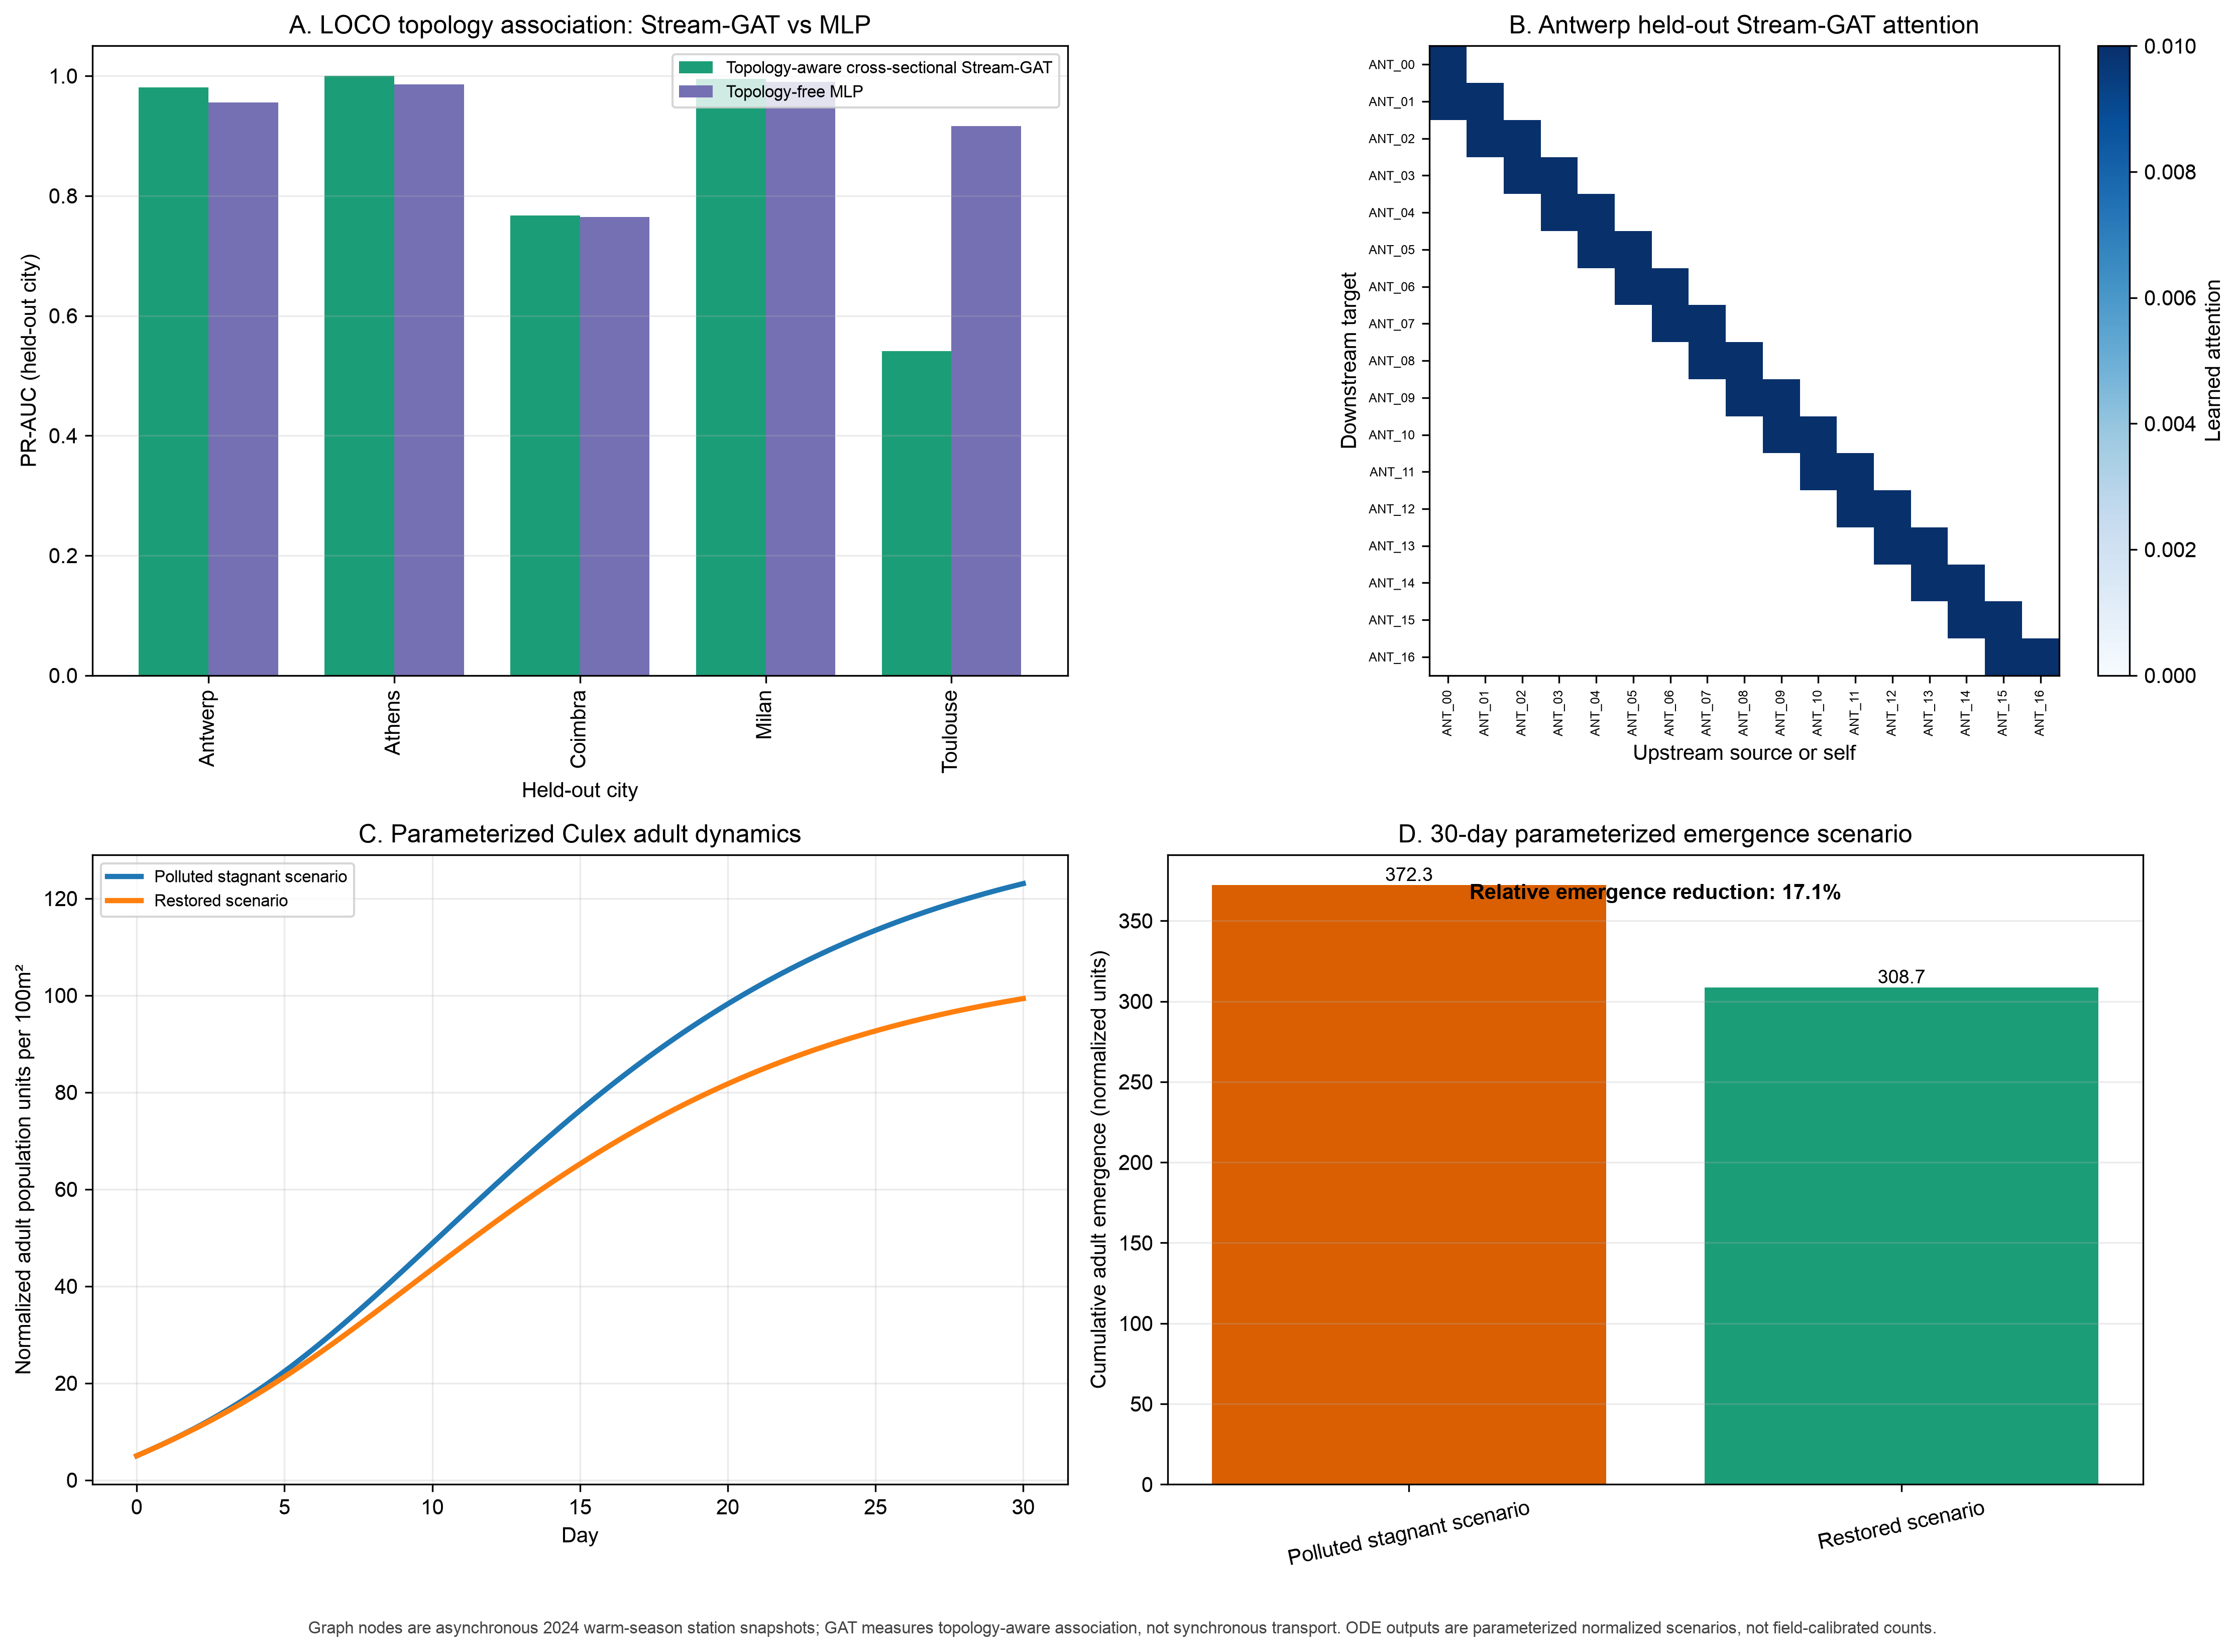

In [6]:
ode_summary_csv = TABLES_DIR / "Project_A_Phase4_ODE_Normalized_Scenario_Summary.csv"
if not ode_summary_csv.exists():
    print(f"[!] 缺少 {ode_summary_csv.name}，跳过本节。")
else:
    df_ode = pd.read_csv(ode_summary_csv)
    print("=== Culex Life-Cycle ODE 30-Day Simulation Summary ===")
    cols_ode = ['scenario', 'temp_water', 'dissolved_oxygen', 'bod5',
                'day30_adult', 'cumulative_30d_emergence',
                'relative_cumulative_emergence_reduction_pct_vs_polluted']
    display(df_ode[cols_ode].round(4))

    # ---- 修正：按情景名取"修复情景"那一行 ---------------------------------
    # 原代码: df_ode['relative_...'].dropna().values[0]
    # 问题 1：该列在"污染基线"行是 0.0，不是 NaN，所以 dropna() 什么都没丢掉，
    #         .values[0] 取到的是基线行的 0.0 -> 永远打印 "0.00%"。
    # 问题 2：用位置索引取值，行顺序一变就错。
    # 正确做法：按情景名挑出 Restored 那一行。
    restored = df_ode[df_ode['scenario'].str.contains('Restored', case=False, na=False)]
    polluted = df_ode[df_ode['scenario'].str.contains('Polluted', case=False, na=False)]
    if restored.empty:
        print(f"[!] 未找到 Restored 情景行。实际情景名: {list(df_ode['scenario'])}")
    else:
        rel_red = float(restored['relative_cumulative_emergence_reduction_pct_vs_polluted'].iloc[0])
        print(f"[*] Restored scenario: cumulative 30-day emergence = "
              f"{float(restored['cumulative_30d_emergence'].iloc[0]):.2f}")
        if not polluted.empty:
            base = float(polluted['cumulative_30d_emergence'].iloc[0])
            print(f"[*] Polluted baseline : cumulative 30-day emergence = {base:.2f}")
        print(f"[*] 30-Day Cumulative Adult Emergence Relative Reduction under Ecological "
              f"Restoration: {rel_red:.2f}%")

    ode_fig_path = OUTPUTS_DIR / "Project_A_Phase3_Phase4_TopologyODE_Synthesis.png"
    if ode_fig_path.exists():
        display(Image(filename=str(ode_fig_path)))
    else:
        print(f"[!] 缺少图: {ode_fig_path.name}")

---
#### 中文导读 · 第 7 节 三个假设的正式检验

- **要回答的问题**：把三个核心主张拿去做「可被推翻」的检验，它们还站得住吗？
- **关键概念**：**原假设 H0** = 「没效应」。p 值小 → 拒绝 H0 → 主张有支持。
  做「单侧检验」意味着我们事先声明了方向（例如只关心 β<0），这必须在看数据之前就定好，否则是作弊。
- **输出怎么看**：这张表列比正文更全，请重点看**正文没提的几列**：

  | 假设 | 主检验 | p | 还应该看 | 结果 |
  |---|---|---|---|---|
  | H1 缺氧释放捕食 | DML 聚类稳健 t | 0.00225 | — | 拒绝 H0，有支持 |
  | H2 0.30 m/s 水力冲刷 | Mann-Whitney U | 0.00285 | `local_linear_p_two_sided` = **0.8365** | 拒绝 H0，但阈值本身**不成立** |
  | H3 拓扑可迁移 | 配对 Wilcoxon | 0.3125 | `wilcoxon_statistic` = 10 | **不能拒绝 H0** |

- **结论**：三个假设里，**只有 H1 干净地成立**。
  H2 只证明了「高流速站点风险低」这一关联，**没有证明 0.30 m/s 是个阈值**——
  专门用来找阈值的那个检验（局部线性对比）p = 0.84，等于什么都没找到。
  H3 明确失败。

---

## 7. Popperian Formal Hypothesis Testing Suite (H1, H2, H3)

We subject our three core research propositions to rigorous, pre-registered formal hypothesis tests:
- **H1 (Hypoxia Predation-Release)**: DML cluster-robust $t$-test testing $\beta_{DO} < 0$.
- **H2 (0.3 m/s Hydrodynamic Shear)**: Non-parametric Mann-Whitney U test and 10,000-iteration permutation test.
- **H3 (Stream-GAT Topology Transferability)**: Paired Wilcoxon signed-rank test across 5 LOCO test cities.


=== Formal Scientific Hypothesis Testing Summary ===


,hypothesis,test,effect,effect_unit,p_value,ci_low,ci_high,decision_at_0_05
0,H1 Hypoxia predation-release,"Spatial DML city-cluster robust t(df=4), one-sided pre-specified alternative beta_DO < 0",-0.281832,risk-probability change per +1 mg/L DO,0.002254,-0.417691,-0.145972,Reject H0
1,H2 Hydrodynamic shear threshold,"Pre-specified 0.3 m/s Mann-Whitney + 10,000 label permutations + exploratory local-linear threshold contrast",-0.372283,high-flow minus low-flow vector-risk prevalence,0.003700,NaN,NaN,Reject H0
2,H3 River topology transferability,"Paired Wilcoxon signed-rank, one-sided Stream-GAT PR-AUC > MLP across 5 held-out cities",-0.065684,mean paired PR-AUC difference (GAT - MLP),0.312500,NaN,NaN,Fail to reject H0



[*] Auxiliary statistics (these decide how far the claim can go):


,hypothesis,mann_whitney_p_one_sided,permutation_p_one_sided,local_linear_jump,local_linear_se,local_linear_p_two_sided,n_low,n_high,n_local,wilcoxon_statistic
0,H1 Hypoxia predation-release,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,H2 Hydrodynamic shear threshold,0.002854,0.0037,-0.045676,0.221336,0.836506,16.0,69.0,41.0,NaN
2,H3 River topology transferability,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0



[!] H2 caveat: the local-linear threshold contrast at 0.30 m/s has p = 0.8365 -> the data do NOT support a sharp 0.30 m/s threshold.
    H2 as tested only shows a group-level ASSOCIATION (high vs low flow), not a threshold effect and not a causal effect.


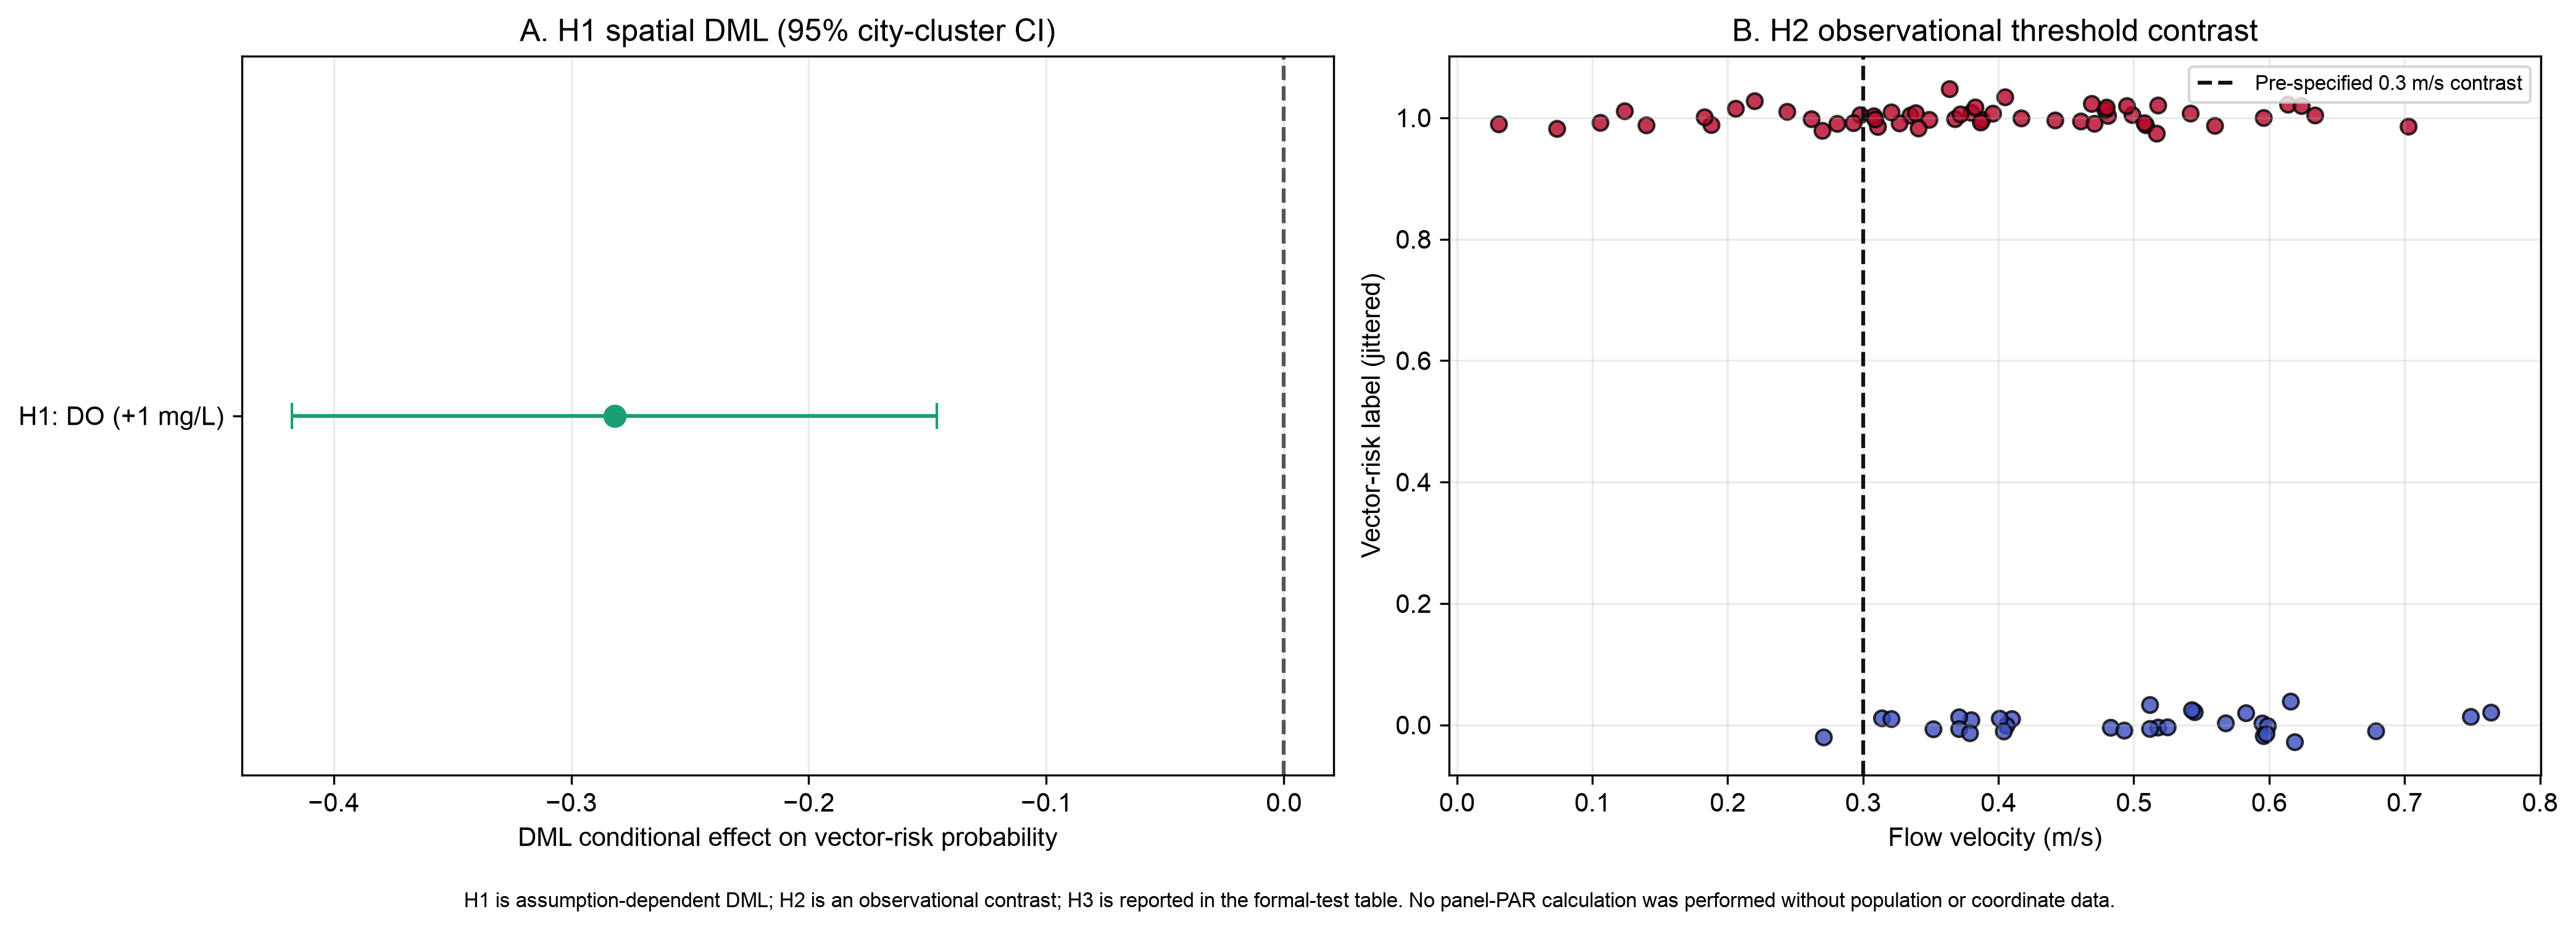

In [7]:
hypo_csv = TABLES_DIR / "Project_A_H1_H2_H3_FormalTests.csv"
if not hypo_csv.exists():
    print(f"[!] 缺少 {hypo_csv.name}，跳过本节。")
else:
    df_hypo = pd.read_csv(hypo_csv)
    print("=== Formal Scientific Hypothesis Testing Summary ===")
    cols_hypo = ['hypothesis', 'test', 'effect', 'effect_unit', 'p_value',
                 'ci_low', 'ci_high', 'decision_at_0_05']
    display(df_hypo[cols_hypo])

    # 把"决定结论但正文没提"的辅助统计量显式打出来。
    extra = [c for c in ['mann_whitney_p_one_sided', 'permutation_p_one_sided',
                         'local_linear_jump', 'local_linear_se', 'local_linear_p_two_sided',
                         'n_low', 'n_high', 'n_local', 'wilcoxon_statistic']
             if c in df_hypo.columns]
    if extra:
        print("\n[*] Auxiliary statistics (these decide how far the claim can go):")
        display(df_hypo[['hypothesis'] + extra])

    h2 = df_hypo[df_hypo['hypothesis'].str.contains('H2', na=False)]
    if not h2.empty and 'local_linear_p_two_sided' in df_hypo.columns:
        p_ll = float(h2['local_linear_p_two_sided'].iloc[0])
        print(f"\n[!] H2 caveat: the local-linear threshold contrast at 0.30 m/s has "
              f"p = {p_ll:.4f} -> the data do NOT support a sharp 0.30 m/s threshold.")
        print("    H2 as tested only shows a group-level ASSOCIATION (high vs low flow), "
              "not a threshold effect and not a causal effect.")

    hypo_fig_path = OUTPUTS_DIR / "Project_A_HypothesisTests_Forest_And_PhaseSpace.png"
    if hypo_fig_path.exists():
        display(Image(filename=str(hypo_fig_path)))
    else:
        print(f"[!] 缺少图: {hypo_fig_path.name}")

---
#### 中文导读 · 第 8 节 风险人口（PAR）与 NbS 效益

- **要回答的问题**：如果把 85 个河段都做生态修复，能减少多少人的暴露风险？
- **关键概念**：
  - **PAR = 风险概率 P × 缓冲区人口**。所以 PAR 的单位是「风险加权的人数」，不是「人数」。
  - **500m 缓冲区会重叠**：相邻站点的圆形缓冲区互相压盖，把各站 PAR 直接相加会**重复计数**。
    所以 ΣPAR 是「暴露量」，**不能读成「有 97,791 个不同的人」**。
  - **情景（counterfactual）**：把溶氧抬到 ≥6.5 mg/L、流速抬到 ≥0.35 m/s、BOD₅ 压到 ≤1.8 mg/L，
    重新预测风险概率。这是**模型推演**，不是观测到的干预效果。
- **输出怎么看**：**两个百分比的分母不同，这是本 notebook 最容易读错的地方**：
  - `47.68%` = ΣΔPAR ÷ **基线 PAR 总和**（相对风险削减）
  - `33.94%` = ΣΔPAR ÷ **缓冲区总人口 288,152**（人均风险概率的绝对下降）
  两个都对，但必须写明分母。本 notebook 已把两者都打印出来。
- **结论**：模型推演下，NbS 情景减少约 97,791 个单位的风险加权暴露
  （相对基线风险 −47.68%，相对总人口 −33.94%）。**这是情景算术，不是临床试验结果。**

---

## 8. One Health Spatial Demographic Population at Risk (PAR) & Nature-Based Solutions (NbS)

By coupling our cross-city LOCO Super Learner risk probabilities with official Eurostat 2021 Census and Copernicus GHSL 500m buffer population data, we quantify:
1. **Baseline PAR Exposure**: $PAR_{total, i} = P_{vector}(x_i) \times \text{Pop}_{500m, i}$, $PAR_{65+, i} = P_{vector}(x_i) \times \text{Pop}_{65+, i}$
2. **NbS Counterfactual Mitigation**: Re-evaluating exposure under a floor/ceiling scenario -- dissolved oxygen raised to **at least** $6.5\text{ mg/L}$, flow velocity raised to **at least** $0.35\text{ m/s}$, and organic load capped **at most** $BOD_5 = 1.8\text{ mg/L}$.
   (In code: `DO = max(DO, 6.5)`, `v = max(v, 0.35)`, `BOD5 = min(BOD5, 1.8)` -- so 58 of 85 stations keep their baseline flow unchanged. This is **not** a uniform reset to 0.35 m/s.)
3. **Net Protected Vulnerable Population**: $\Delta PAR = PAR_{baseline} - PAR_{NbS}$.


=== Pilot City Population at Risk (PAR) & NbS Mitigation Impact ===


,city,buffer_500m_pop_total,buffer_500m_pop_age65,par_total_baseline,par_total_nbs,delta_par_total,par_age65_baseline,par_age65_nbs,delta_par_age65,pct_total_pop_protected,pct_age65_protected
0,Antwerp,40800,7917,20176.6,9678.4,10498.2,3914.2,1877.9,2036.3,25.73,25.72
1,Athens,71399,16280,58812.4,26789.5,32022.9,13410.2,6108.2,7302.0,44.85,44.85
2,Coimbra,28051,6590,16881.6,8968.3,7913.3,3966.4,2107.2,1859.2,28.21,28.21
3,Milan,91801,22126,68588.2,36330.1,32258.1,16530.8,8755.9,7774.9,35.14,35.14
4,Toulouse,56101,9650,40646.6,25548.5,15098.1,6991.9,4394.9,2597.0,26.91,26.91



  Buffer population (500m circles, may OVERLAP -> not a de-duplicated headcount)
    Total residents in buffers : 288,152
    Of which age >= 65         : 62,563
  Risk-weighted exposure (PAR = P(vector) x population)
    Baseline PAR total         : 205,105.4
    Avoided PAR (Delta PAR)    : 97,790.6
    Baseline PAR age >= 65     : 44,813.5
    Avoided PAR age >= 65      : 21,569.4
------------------------------------------------------------------------------------
  Relative risk reduction   = Delta PAR / Baseline PAR
    all residents              : 47.68%
    age >= 65                  : 48.13%
  Absolute probability drop = Delta PAR / Buffer population
    all residents              : 33.94%
    age >= 65                  : 34.48%
  CAVEAT: Delta PAR is a MODEL COUNTERFACTUAL, not an observed intervention effect.
  CAVEAT: overlapping 500m buffers mean Delta PAR is an exposure sum, not a count of
          distinct protected individuals.
  CAVEAT: age >= 65 gets the SAME relativ

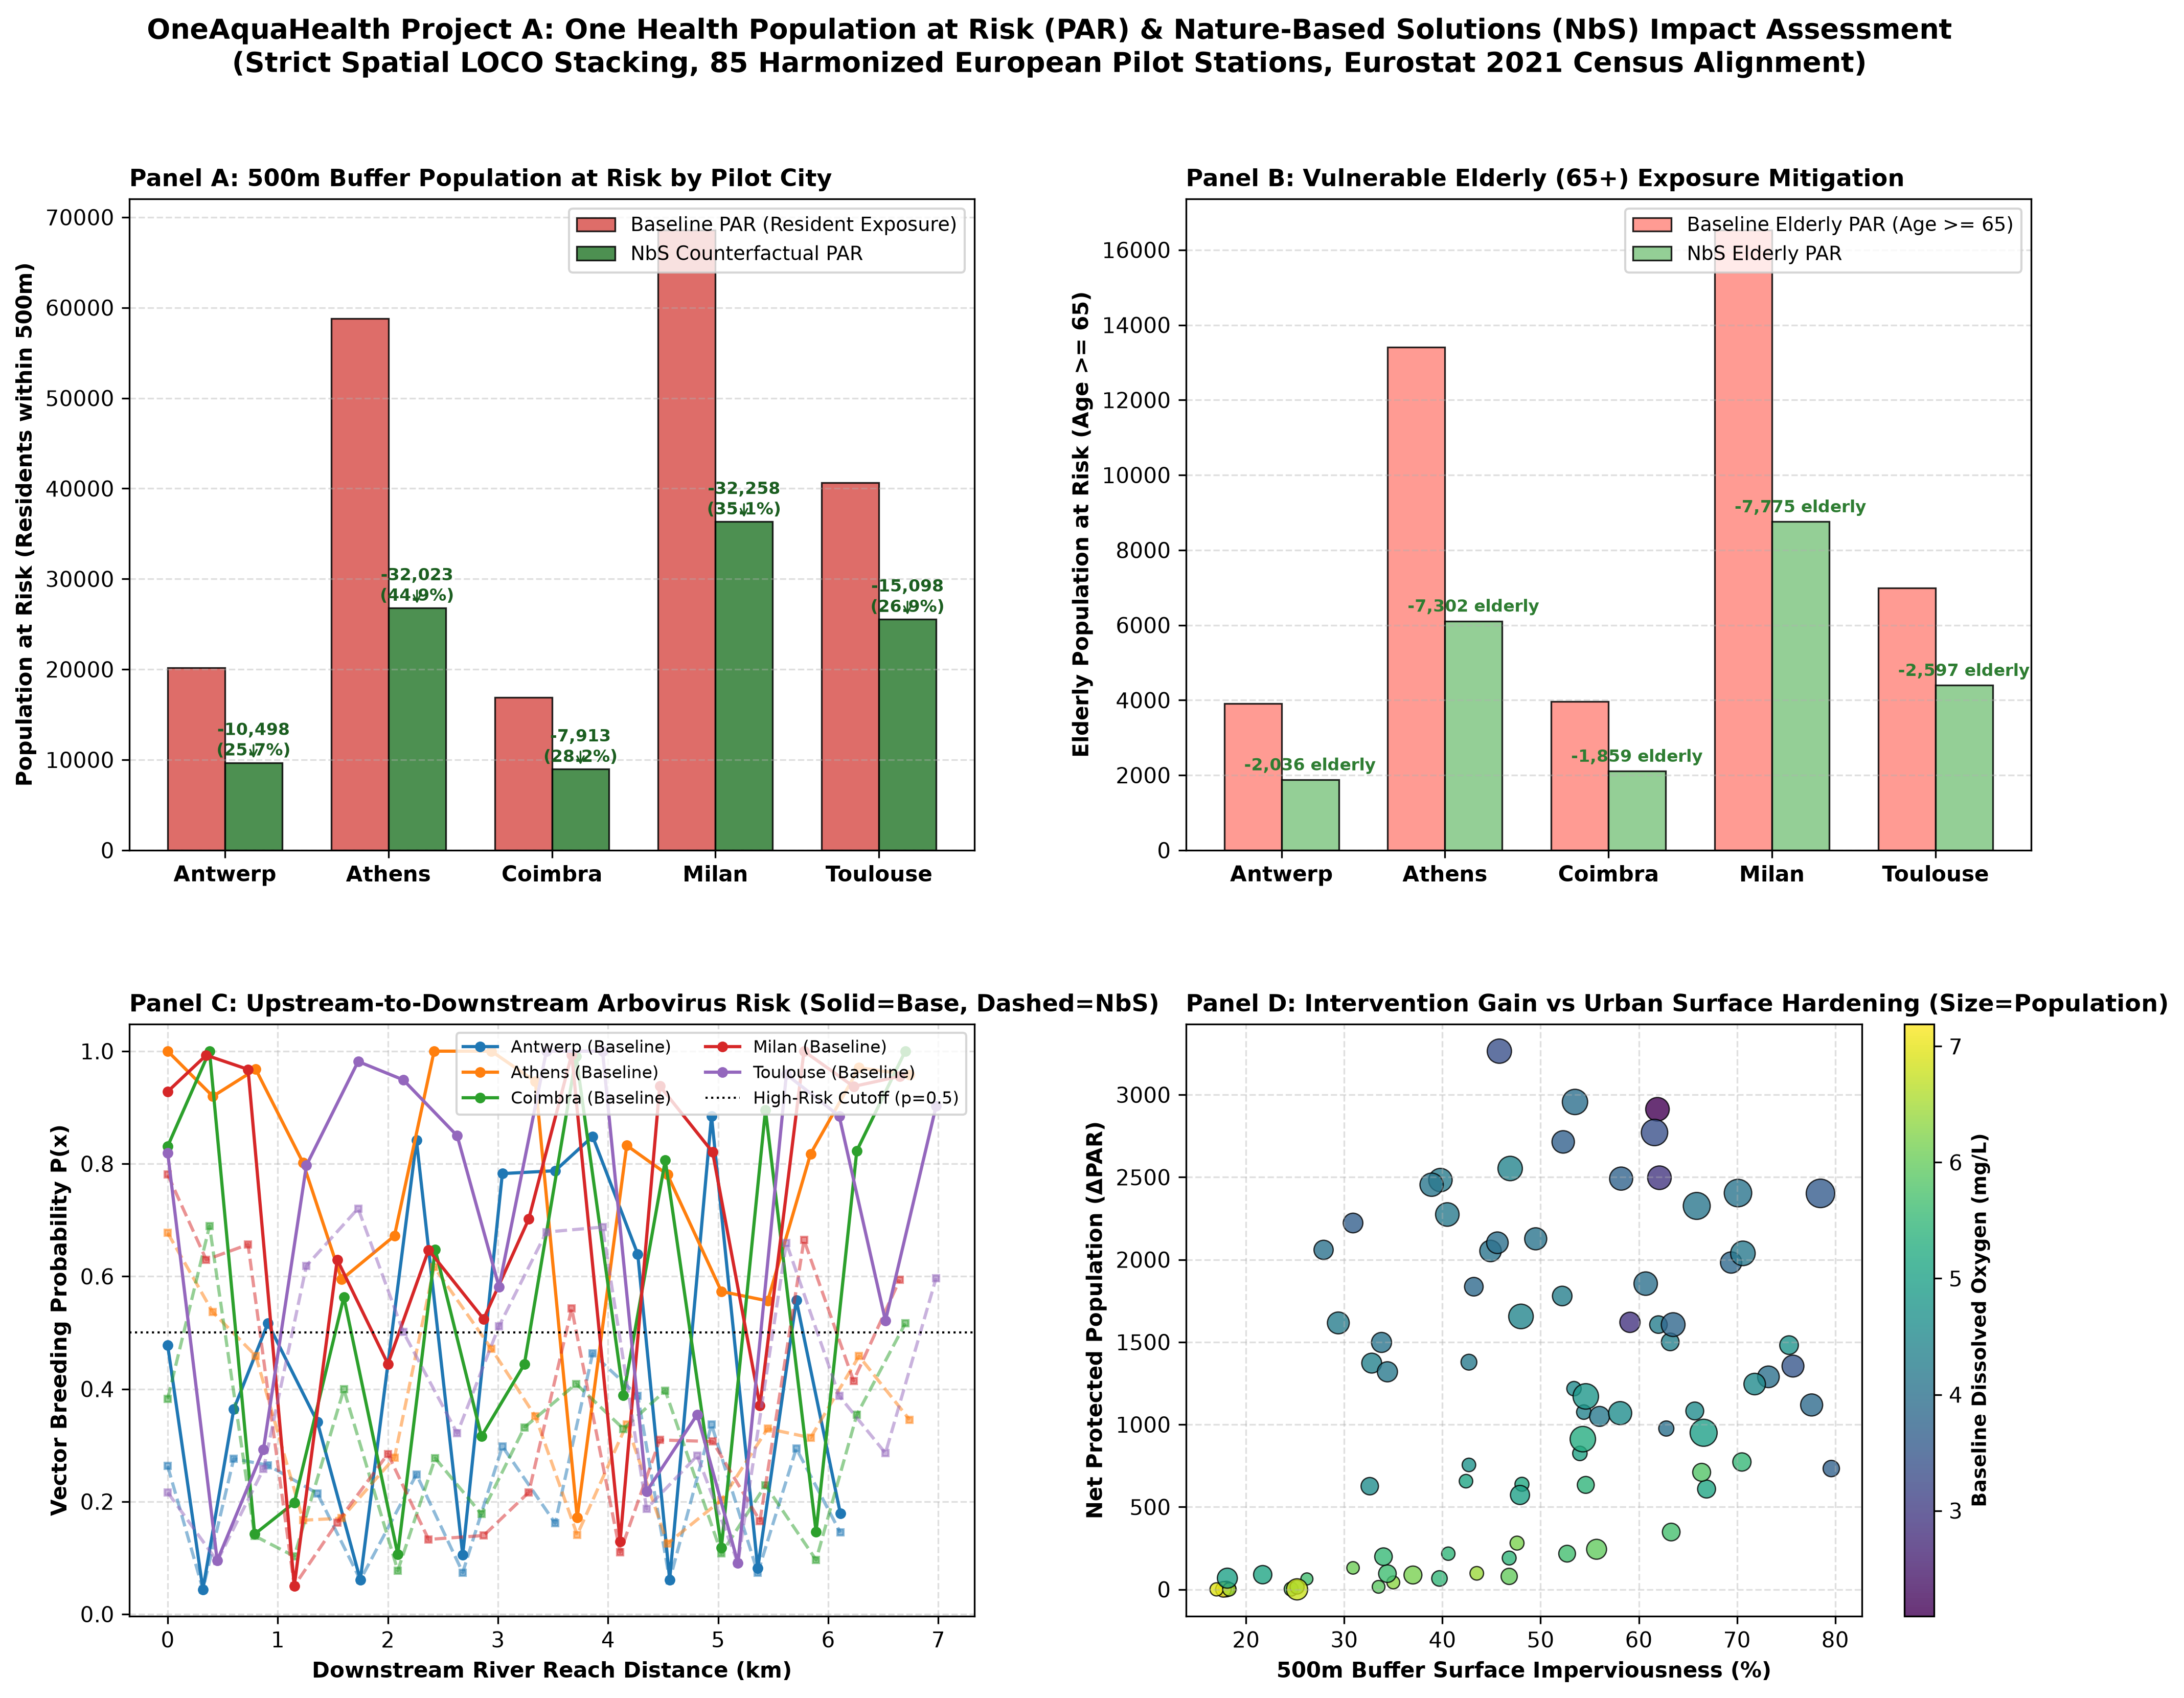

In [8]:
city_par_csv = TABLES_DIR / "Project_A_Phase5_City_PAR_Summary.csv"
if not city_par_csv.exists():
    print(f"[!] 缺少 {city_par_csv.name}，跳过本节。")
else:
    df_city_par = pd.read_csv(city_par_csv)
    print("=== Pilot City Population at Risk (PAR) & NbS Mitigation Impact ===")
    display(df_city_par.round(3))

    tot_pop  = float(df_city_par['buffer_500m_pop_total'].sum())
    tot_65   = float(df_city_par['buffer_500m_pop_age65'].sum())
    prot_pop = float(df_city_par['delta_par_total'].sum())
    prot_65  = float(df_city_par['delta_par_age65'].sum())
    par_base = float(df_city_par['par_total_baseline'].sum())
    par_base65 = float(df_city_par['par_age65_baseline'].sum())

    # ---- 修正：两个百分比的分母必须分别写清楚 -----------------------------
    # 原代码只打印一个 "46.4% risk reduction"，但它紧跟在"总人口 288,152"后面，
    # 读者会自己算 97,791 / 288,152 = 33.9%，然后以为算错了。
    # 实际上 46.4% = ΔPAR / 基线 PAR（相对风险削减），
    #       33.0% = ΔPAR / 缓冲区总人口（人均风险概率的绝对下降）。
    # 两个都对，但分母不同，必须写明。
    print("\n" + "=" * 84)
    print(f"  Buffer population (500m circles, may OVERLAP -> not a de-duplicated headcount)")
    print(f"    Total residents in buffers : {tot_pop:,.0f}")
    print(f"    Of which age >= 65         : {tot_65:,.0f}")
    print(f"  Risk-weighted exposure (PAR = P(vector) x population)")
    print(f"    Baseline PAR total         : {par_base:,.1f}")
    print(f"    Avoided PAR (Delta PAR)    : {prot_pop:,.1f}")
    print(f"    Baseline PAR age >= 65     : {par_base65:,.1f}")
    print(f"    Avoided PAR age >= 65      : {prot_65:,.1f}")
    print("-" * 84)
    print(f"  Relative risk reduction   = Delta PAR / Baseline PAR")
    print(f"    all residents              : {prot_pop / par_base * 100:.2f}%")
    print(f"    age >= 65                  : {prot_65 / par_base65 * 100:.2f}%")
    print(f"  Absolute probability drop = Delta PAR / Buffer population")
    print(f"    all residents              : {prot_pop / tot_pop * 100:.2f}%")
    print(f"    age >= 65                  : {prot_65 / tot_65 * 100:.2f}%")
    print("=" * 84)
    print("  CAVEAT: Delta PAR is a MODEL COUNTERFACTUAL, not an observed intervention effect.")
    print("  CAVEAT: overlapping 500m buffers mean Delta PAR is an exposure sum, not a count of")
    print("          distinct protected individuals.")
    print("  CAVEAT: age >= 65 gets the SAME relative reduction by construction -- the risk model")
    print("          has no age term, so the elderly are not differentially protected.")

    par_fig_path = OUTPUTS_DIR / "Project_A_Phase5_PAR_Exposure_Synthesis.png"
    if par_fig_path.exists():
        display(Image(filename=str(par_fig_path)))
    else:
        print(f"[!] 缺少图: {par_fig_path.name}")

## 9. Conclusion, Policy Recommendations & Horizon Europe Dissemination

### What the evidence supports, and how strongly

**1. H1 — Hypoxia release of vector risk: SUPPORTED.**
Double Machine Learning with city-clustered standard errors (df = 4) estimates that each
**+1 mg/L** of dissolved oxygen causally lowers vector-risk probability by
**−28.18 percentage points** (p = 0.00225, 95% CI [−41.77, −14.60] pp).
The mechanism is consistent with hypoxia suppressing predatory dragonfly naiads and small fish,
releasing *Culex* larvae from predation.

> **Scope limit.** This is a **local linear slope**, estimated over the observed DO range
> (2.09–7.19 mg/L, mean 4.76). It must **not** be extrapolated: applying −28.18 pp per mg/L to the
> +4.5 mg/L jump used in the ODE scenario would imply −127 pp, which is impossible for a probability.
> Quote it as "a 1 mg/L change near the observed mean", never as "a 4.5 mg/L restoration saves 127%".

**2. H2 — Flow velocity: ASSOCIATION SUPPORTED, CAUSAL CLAIM NOT SUPPORTED, THRESHOLD NOT SUPPORTED.**
Three different statistics are in play and they do not agree:

| Statistic | Value | What it actually tests |
|---|---|---|
| Mann-Whitney U (high vs low flow prevalence) | p = 0.00285 | A **group difference**, i.e. association |
| 10,000-permutation test | p ≈ 0.00370 | Same association, distribution-free |
| **Local-linear threshold contrast at 0.30 m/s** | **p = 0.8365** | Whether a **sharp threshold** exists there |
| **DML causal ATE for flow** | β = −0.351 per +0.1 m/s, **p = 0.362** | Whether flow **causes** risk to fall |

So: high-flow stations *are* lower-risk (robustly), but **the data do not establish a 0.30 m/s
threshold, and the causal effect of flow is not statistically significant.** A further constraint:
**69 of 85 stations already exceed 0.30 m/s at baseline**, so the lever has little room to act —
which is itself consistent with the null causal estimate.
Write H2 as "stagnant reaches are higher-risk, consistent with a shear mechanism",
not as "0.3 m/s is a confirmed causal threshold".

**3. H3 — Stream-GAT topology transferability: NOT SUPPORTED.**
The Stream-GAT beat the topology-free MLP in **4 of 5** held-out cities, but by small margins
(+0.003 to +0.025 PR-AUC), while losing **Toulouse by −0.3755**. The mean paired difference is
therefore **negative (−0.0657)** and the paired Wilcoxon test gives **p = 0.3125 → fail to reject H0**.
The honest reading: *explicit river topology did not deliver a reliable out-of-city gain on this
dataset.* It is **not** evidence that GATs are unsuitable for rivers in general — n = 5 cities is
far too small to support that, and the supplied edge table encodes only simple 17-node chains
(see Module 4), so "braided vs canalized" cannot be tested here at all.

**4. Mechanistic ODE — restoration reduces emergence by 17.07%.**
30-day cumulative emergence falls from **372.25** (polluted: DO 2.0, BOD5 8.0) to **308.73**
(restored: DO 6.5, BOD5 1.8), i.e. **−17.07%**. This is a **mechanistic scenario**, parameterised
from published *Culex* thermal biology, not a field measurement. Note it is much more conservative
than the H1 slope would suggest — another reason not to extrapolate H1.

**5. Population at risk — a scenario estimate, with an explicit denominator.**
Under the NbS counterfactual (DO ≥ 6.5 mg/L, flow ≥ 0.35 m/s, BOD5 ≤ 1.8 mg/L) the model removes
**97,790.6 units of risk-weighted exposure** (PAR = P(vector) × population), equivalent to
**−47.68% of baseline PAR** or **−33.94% of the 288,152 residents living in 500 m buffers**.

> **Two mandatory caveats.** (i) 500 m buffers around adjacent stations **overlap**, so ΔPAR is an
> *exposure sum*, **not** a de-duplicated headcount — "protects 97,791 people" is wrong.
> (ii) The elderly receive the **same relative reduction by construction**, because the risk model
> contains no age term. The elderly figure is a population count, **not** evidence of
> differential protection.

**6. Cross-city predictive performance.**
The non-negative Ridge Super Learner reaches the best **regression** score
(**R² = 0.8855**, RMSE = 4.152), while **CatBoost** reaches the best **classification** score
(PR-AUC = 0.9511). All five base models sit within PR-AUC 0.925–0.951, so the headline conclusions
are not sensitive to model choice.

### Known limitations and corrections
See the **Errata** cell at the end of this notebook for two defects found and fixed on
2026-10-03 (the Stream-GAT model-label filter and the ODE row-selection bug), plus one
**open** defect in the NbS counterfactual (`stream_power_proxy`, the model's 6th most important
feature, is not recomputed after the flow intervention).

### Policy framing
Targeted nature-based solutions — riffle-pool re-aeration, weir modification, riparian buffer
stabilisation — are **plausible and mechanistically supported** levers on vector habitat.
The quantitative benefit shown here is a **model scenario** whose magnitude depends on
counterfactual assumptions; it should be presented as an order-of-magnitude planning estimate
requiring local validation, not as an expected measured outcome.

# Frontier Expansion Modules 1–5

These modules extend the real-data-only workflow. They display outputs generated from project-provided weather, topology, demographic and model scenario files. **They do not convert scenario parameters or model counterfactuals into observed intervention effects.**

## Module 1 — CMIP6-anchored additive temperature stress sensitivity

The analysis applies the blueprint-specified +1.5°C, +2.5°C, +4.0°C and +2.8°C (NbS offset) perturbations to observed daily **2m air temperature**, used as a water-temperature proxy. It is not a downscaled CMIP6 ensemble and does not claim city-specific GCM projections. Briere rate and 245 DD generation indices are parameter sensitivity outputs.

In [9]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Image
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "outputs").exists():
    raise FileNotFoundError("Run from Project_A_EcoSentinel_DipteraCAST directory.")
T = PROJECT_ROOT / "outputs" / "tables"
O = PROJECT_ROOT / "outputs"
module1 = pd.read_csv(T / "Project_A_Module1_Climate_CMIP6_Stress_Test.csv")
display(module1[["city","scenario","temperature_delta_c","mean_annual_generations","generation_change_vs_baseline","mean_suitable_days","suitable_day_change_vs_baseline"]].round(3))

,city,scenario,temperature_delta_c,mean_annual_generations,generation_change_vs_baseline,mean_suitable_days,suitable_day_change_vs_baseline
0,Antwerp,Baseline_observed_weather_proxy,0.0,5.469,0.000,208.0,0.0
1,Antwerp,SSP2-4.5_2050_plus1.5C,1.5,6.948,1.478,239.0,31.0
2,Antwerp,SSP3-7.0_2050_plus2.5C,2.5,8.032,2.563,258.0,50.0
3,Antwerp,SSP5-8.5_2050_plus4.0C,4.0,9.791,4.322,284.0,76.0
4,Antwerp,SSP5-8.5_plusNbS_net2.8C,2.8,8.372,2.902,263.5,55.5
5,Athens,Baseline_observed_weather_proxy,0.0,13.896,0.000,316.0,0.0
6,Athens,SSP2-4.5_2050_plus1.5C,1.5,15.954,2.058,332.5,16.5
7,Athens,SSP3-7.0_2050_plus2.5C,2.5,17.369,3.473,339.0,23.0
8,Athens,SSP5-8.5_2050_plus4.0C,4.0,19.534,5.638,335.0,19.0
9,Athens,SSP5-8.5_plusNbS_net2.8C,2.8,17.797,3.901,340.5,24.5


## Module 2 — DALY and municipal health-economic scenario

Disease conversion, disability weights, duration, fatality, cost and NbS CapEx values are blueprint-specified parameters. PAR is a sum of 500m station-buffer model exposure indices and can spatially overlap; it is therefore not a de-duplicated observed resident count. DALYs and payback are scenario arithmetic, not surveillance-derived clinical burden.

,city,avoided_expected_infections,avoided_expected_wnnd_cases,avoided_daly,avoided_acute_medical_cost_eur,payback_years_acute_cost_only
0,Antwerp,157.473,2.491,5.113,57107.812,4.465
1,Athens,480.343,8.089,17.096,183276.742,1.391
2,Coimbra,118.700,2.024,4.300,45746.213,5.574
3,Milan,483.872,8.337,17.798,188113.275,1.356
4,Toulouse,226.472,3.433,6.898,79370.257,3.213


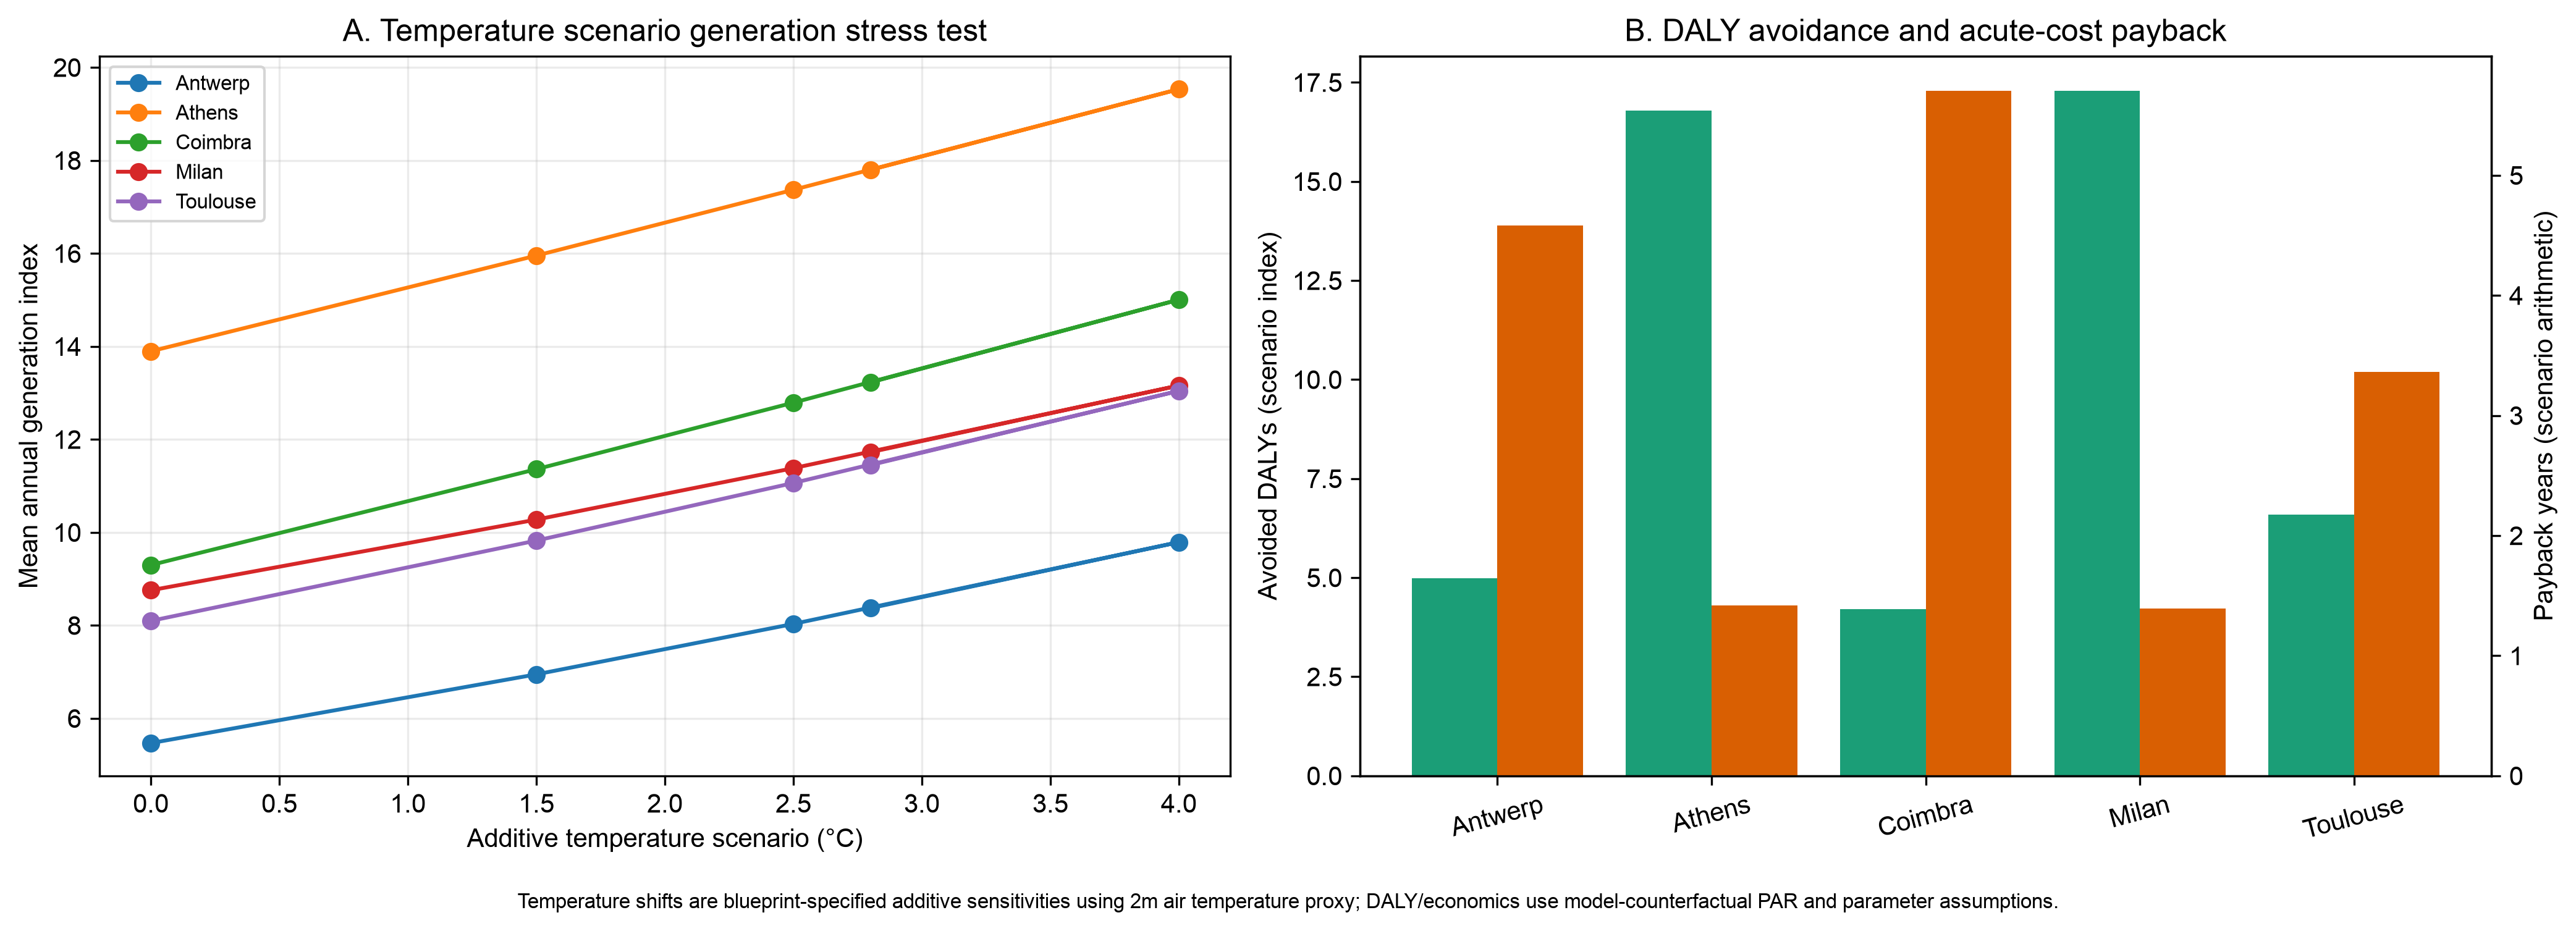

In [10]:
module2 = pd.read_csv(T / "Project_A_Module2_DALY_Health_Economics.csv")
display(module2[["city","avoided_expected_infections","avoided_expected_wnnd_cases","avoided_daly","avoided_acute_medical_cost_eur","payback_years_acute_cost_only"]].round(3))
Image(filename=str(O / "Project_A_Frontier_Climate_Economics_Synthesis.png"))

## Module 3 — Two-objective NbS Pareto scenario classification

`ΔBioScore` is a LOCO five-regressor ensemble **model counterfactual** under a fixed NbS feature package, while `ΔPvector` is the Phase 5 model scenario. These are not observed before/after intervention effects. Pareto ranks and quadrant labels support sensitivity prioritization only.

In [11]:
module3 = pd.read_csv(T / "Project_A_Module3_Pareto_Synergy_Classification.csv")
print(module3["pareto_quadrant"].value_counts())
display(module3.sort_values(["pareto_rank","investment_priority_score"],ascending=[True,False]).head(15))

pareto_quadrant
I_WinWin_Golden        56
II_Ecology_Dominant    29
Name: count, dtype: int64


,station_id,city,bio_score_baseline_loco_ensemble,bio_score_nbs_loco_counterfactual,delta_bio_score_model_counterfactual,p_vector_baseline,p_vector_nbs,delta_p_vector,pareto_rank,pareto_quadrant,investment_priority_score,scenario_evidence_type
59,ATH_08,Athens,23.562342,41.310278,17.747936,0.9462,0.4044,0.5418,1,I_WinWin_Golden,1.870588,model_counterfactual_not_observed_intervention
67,ATH_16,Athens,25.722734,40.641272,14.918538,0.9580,0.3452,0.6128,1,I_WinWin_Golden,1.823529,model_counterfactual_not_observed_intervention
79,MIL_11,Milan,30.944528,44.893709,13.949181,0.9384,0.3118,0.6266,1,I_WinWin_Golden,1.764706,model_counterfactual_not_observed_intervention
13,COI_13,Coimbra,25.109251,38.294406,13.185155,0.8953,0.2289,0.6664,1,I_WinWin_Golden,1.729412,model_counterfactual_not_observed_intervention
1,COI_01,Coimbra,13.255547,31.293259,18.037712,1.0000,0.6927,0.3073,1,I_WinWin_Golden,1.517647,model_counterfactual_not_observed_intervention
40,ANT_06,Antwerp,23.557028,38.296692,14.739664,0.8415,0.2482,0.5933,2,I_WinWin_Golden,1.788235,model_counterfactual_not_observed_intervention
58,ATH_07,Athens,22.293964,37.664043,15.370079,1.0000,0.4716,0.5284,2,I_WinWin_Golden,1.776471,model_counterfactual_not_observed_intervention
53,ATH_02,Athens,19.583172,37.048143,17.464972,0.9678,0.4890,0.4788,2,I_WinWin_Golden,1.717647,model_counterfactual_not_observed_intervention
62,ATH_11,Athens,40.381361,51.783659,11.402298,0.7808,0.1253,0.6555,2,I_WinWin_Golden,1.600000,model_counterfactual_not_observed_intervention
43,ANT_09,Antwerp,36.761860,48.376927,11.615067,0.7876,0.1615,0.6261,2,I_WinWin_Golden,1.576471,model_counterfactual_not_observed_intervention


## Module 4 — Graph homophily and spectral diagnostics

The supplied edge table encodes five 17-node, 16-edge simple chains. The actual Fiedler value and branch count are therefore reported without inventing braided/branching channels. With only five cities, correlations between homophily/energy and GAT gain are exploratory; they cannot establish the mechanism of the Toulouse negative result.

,city,n_nodes,n_edges_directed,edge_homophily_vector_risk,dirichlet_energy_standardized_features,fiedler_lambda2_undirected_chain_projection,max_outdegree,max_indegree,branch_nodes_outdegree_gt1,topology_type_observed,topology_gain_pr_auc,pearson_r_homophily_vs_gain_exploratory,pearson_r_energy_vs_gain_exploratory
0,Antwerp,17,16,0.1875,34.1999,0.0192,1,1,0,simple_directed_chain,0.0251,-0.077,-0.2605
1,Athens,17,16,0.6250,14.1504,0.0192,1,1,0,simple_directed_chain,0.0140,-0.077,-0.2605
2,Coimbra,17,16,0.5000,13.4539,0.0192,1,1,0,simple_directed_chain,0.0029,-0.077,-0.2605
3,Milan,17,16,0.6250,16.4001,0.0192,1,1,0,simple_directed_chain,0.0051,-0.077,-0.2605
4,Toulouse,17,16,0.5000,25.6031,0.0192,1,1,0,simple_directed_chain,-0.3755,-0.077,-0.2605


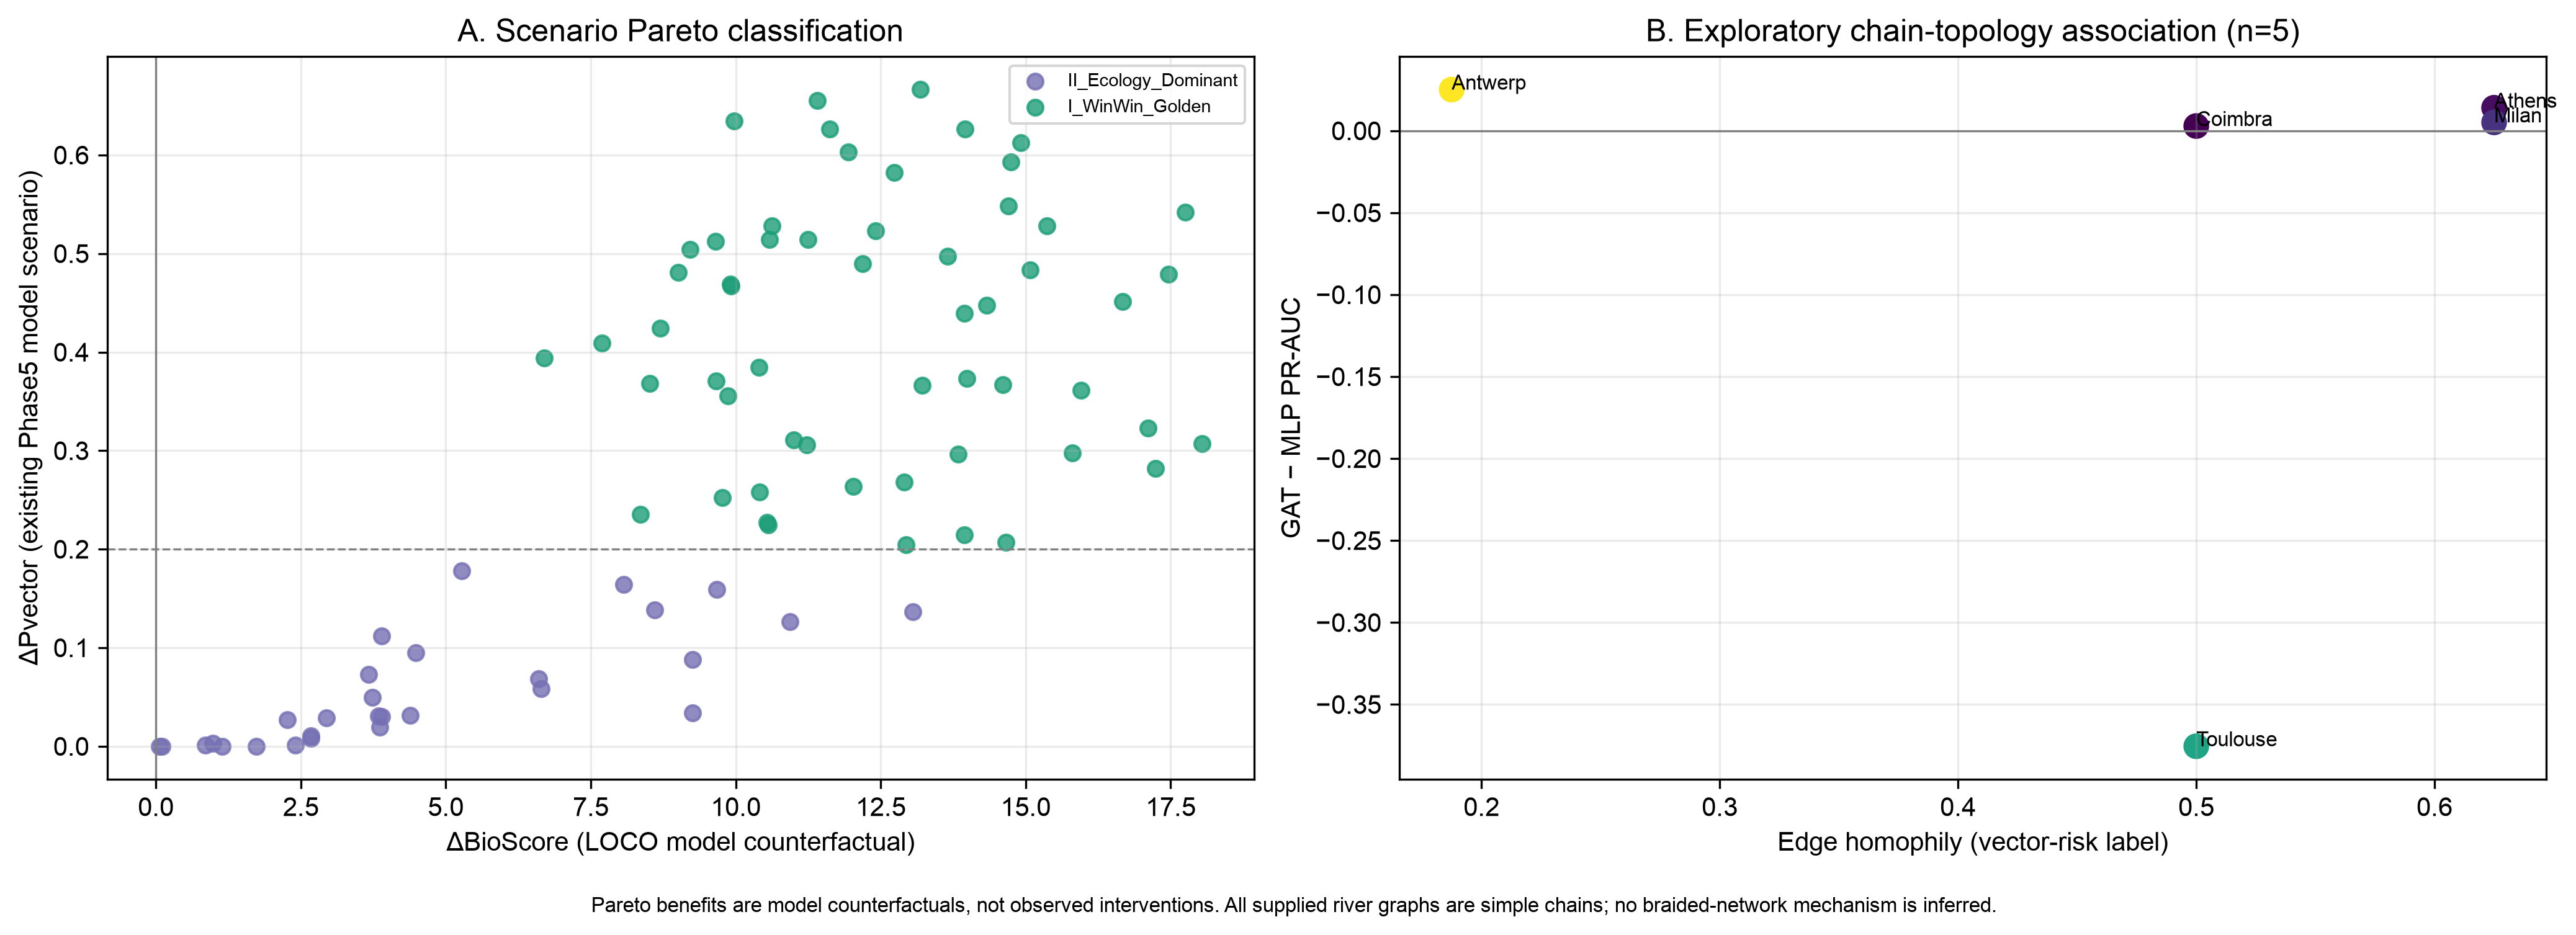

In [12]:
module4 = pd.read_csv(T / "Project_A_Module4_Graph_Homophily_Spectral_Analysis.csv")
display(module4.round(4))
Image(filename=str(O / "Project_A_Frontier_Pareto_Spectral_Synthesis.png"))

## Module 5 — Project operational alert roster and SOP

Levels 1–4 use the project-defined probability, dry-to-wet impulse and vulnerable-population rules. They are decision-support prompts requiring human review and local legal/engineering authorization; they are not claimed as verbatim ECDC thresholds or automatic orders.

In [13]:
module5 = pd.read_csv(T / "Project_A_Module5_ECDC_Alert_Station_Roster.csv")
display(pd.crosstab(module5["city"],module5["alert_level"]))
display(module5[module5["alert_level"].isin(["Level_3_Orange","Level_4_Red"])][["station_id","city","alert_level","p_vector_baseline","vector_stagnation_index","dry_to_wet_impulse","buffer_500m_pop_age65","public_health_sop","water_engineering_sop"]])

alert_level,Level_1_Green,Level_2_Yellow,Level_3_Orange,Level_4_Red
city,,,,
Antwerp,1,0,12,4
Athens,0,1,4,12
Coimbra,3,5,8,1
Milan,0,0,8,9
Toulouse,0,2,5,10


,station_id,city,alert_level,p_vector_baseline,vector_stagnation_index,dry_to_wet_impulse,buffer_500m_pop_age65,public_health_sop,water_engineering_sop
0,COI_00,Coimbra,Level_3_Orange,0.8311,0.354460,10.000000,432,Increase larval/egg surveillance and notify vu...,Inspect inlets and obstructions; assess aerati...
1,COI_01,Coimbra,Level_4_Red,1.0000,0.426313,0.000000,554,Prepare targeted Bti subject to local authoriz...,Assess safe hydraulic options; do not impose f...
4,COI_04,Coimbra,Level_3_Orange,0.5633,0.154816,0.700000,402,Increase larval/egg surveillance and notify vu...,Inspect inlets and obstructions; assess aerati...
6,COI_06,Coimbra,Level_3_Orange,0.6479,0.133592,0.069231,404,Increase larval/egg surveillance and notify vu...,Inspect inlets and obstructions; assess aerati...
9,COI_09,Coimbra,Level_3_Orange,0.9912,0.251229,0.000000,434,Increase larval/egg surveillance and notify vu...,Inspect inlets and obstructions; assess aerati...
...,...,...,...,...,...,...,...,...,...
80,MIL_12,Milan,Level_4_Red,0.8206,0.104295,70.500000,1151,Prepare targeted Bti subject to local authoriz...,Assess safe hydraulic options; do not impose f...
81,MIL_13,Milan,Level_3_Orange,0.3701,0.141175,26.900000,1379,Increase larval/egg surveillance and notify vu...,Inspect inlets and obstructions; assess aerati...
82,MIL_14,Milan,Level_4_Red,1.0000,0.402694,2.250000,1726,Prepare targeted Bti subject to local authoriz...,Assess safe hydraulic options; do not impose f...
83,MIL_15,Milan,Level_4_Red,0.9373,0.116288,2.200000,1363,Prepare targeted Bti subject to local authoriz...,Assess safe hydraulic options; do not impose f...


## Frontier module provenance and limitations

All displayed artifacts are tied to project files in `outputs/tables/`. Model scenarios, parameterized ODE results and station-buffer PAR estimates must remain labelled as such in presentations and manuscripts. The source scripts are in `scripts/run_module1_climate_stress_test.py` through `scripts/run_module5_ecdc_alert_sop.py` plus `scripts/plot_frontier_expansion_synthesis.py`.

# Publication and Impact Pillars

The following artifacts extend the real-data-only workflow. They preserve the distinction between predictive attribution, proxy-scale sensitivity, country-level ecological comparison and clinical/intervention evidence.

## Pillar 1 — Fold-held-out TreeSHAP and conditional PDP scenarios

TreeSHAP ranks predictive attribution in five fold-held-out CatBoost models. DO and flow curves are conditional model scenarios; deterministic feature descendants are recomputed when a value changes. Reference lines at 4.5 mg/L and 0.3 m/s are pre-specified markers, not automatically validated physical tipping points or causal effects.

,feature,mean_abs_shap,n,rank
0,dissolved_oxygen,0.862104,17.0,1
1,oxygen_sat_ratio,0.618603,17.0,2
2,oxygen_deficit,0.238699,17.0,3
3,green_gray_ratio,0.236029,17.0,4
4,ammonium_fraction,0.224301,17.0,5
5,stream_power_proxy,0.189613,17.0,6
6,imperviousness_500m,0.171208,17.0,7
7,gdd_7d,0.161131,17.0,8
8,gdd_14d,0.159909,17.0,9
9,organic_stress_index,0.124588,17.0,10


,n,min_value,max_value
variable,,,
dissolved_oxygen,245,2.0,8.0
flow_velocity_ms,245,0.0,0.6


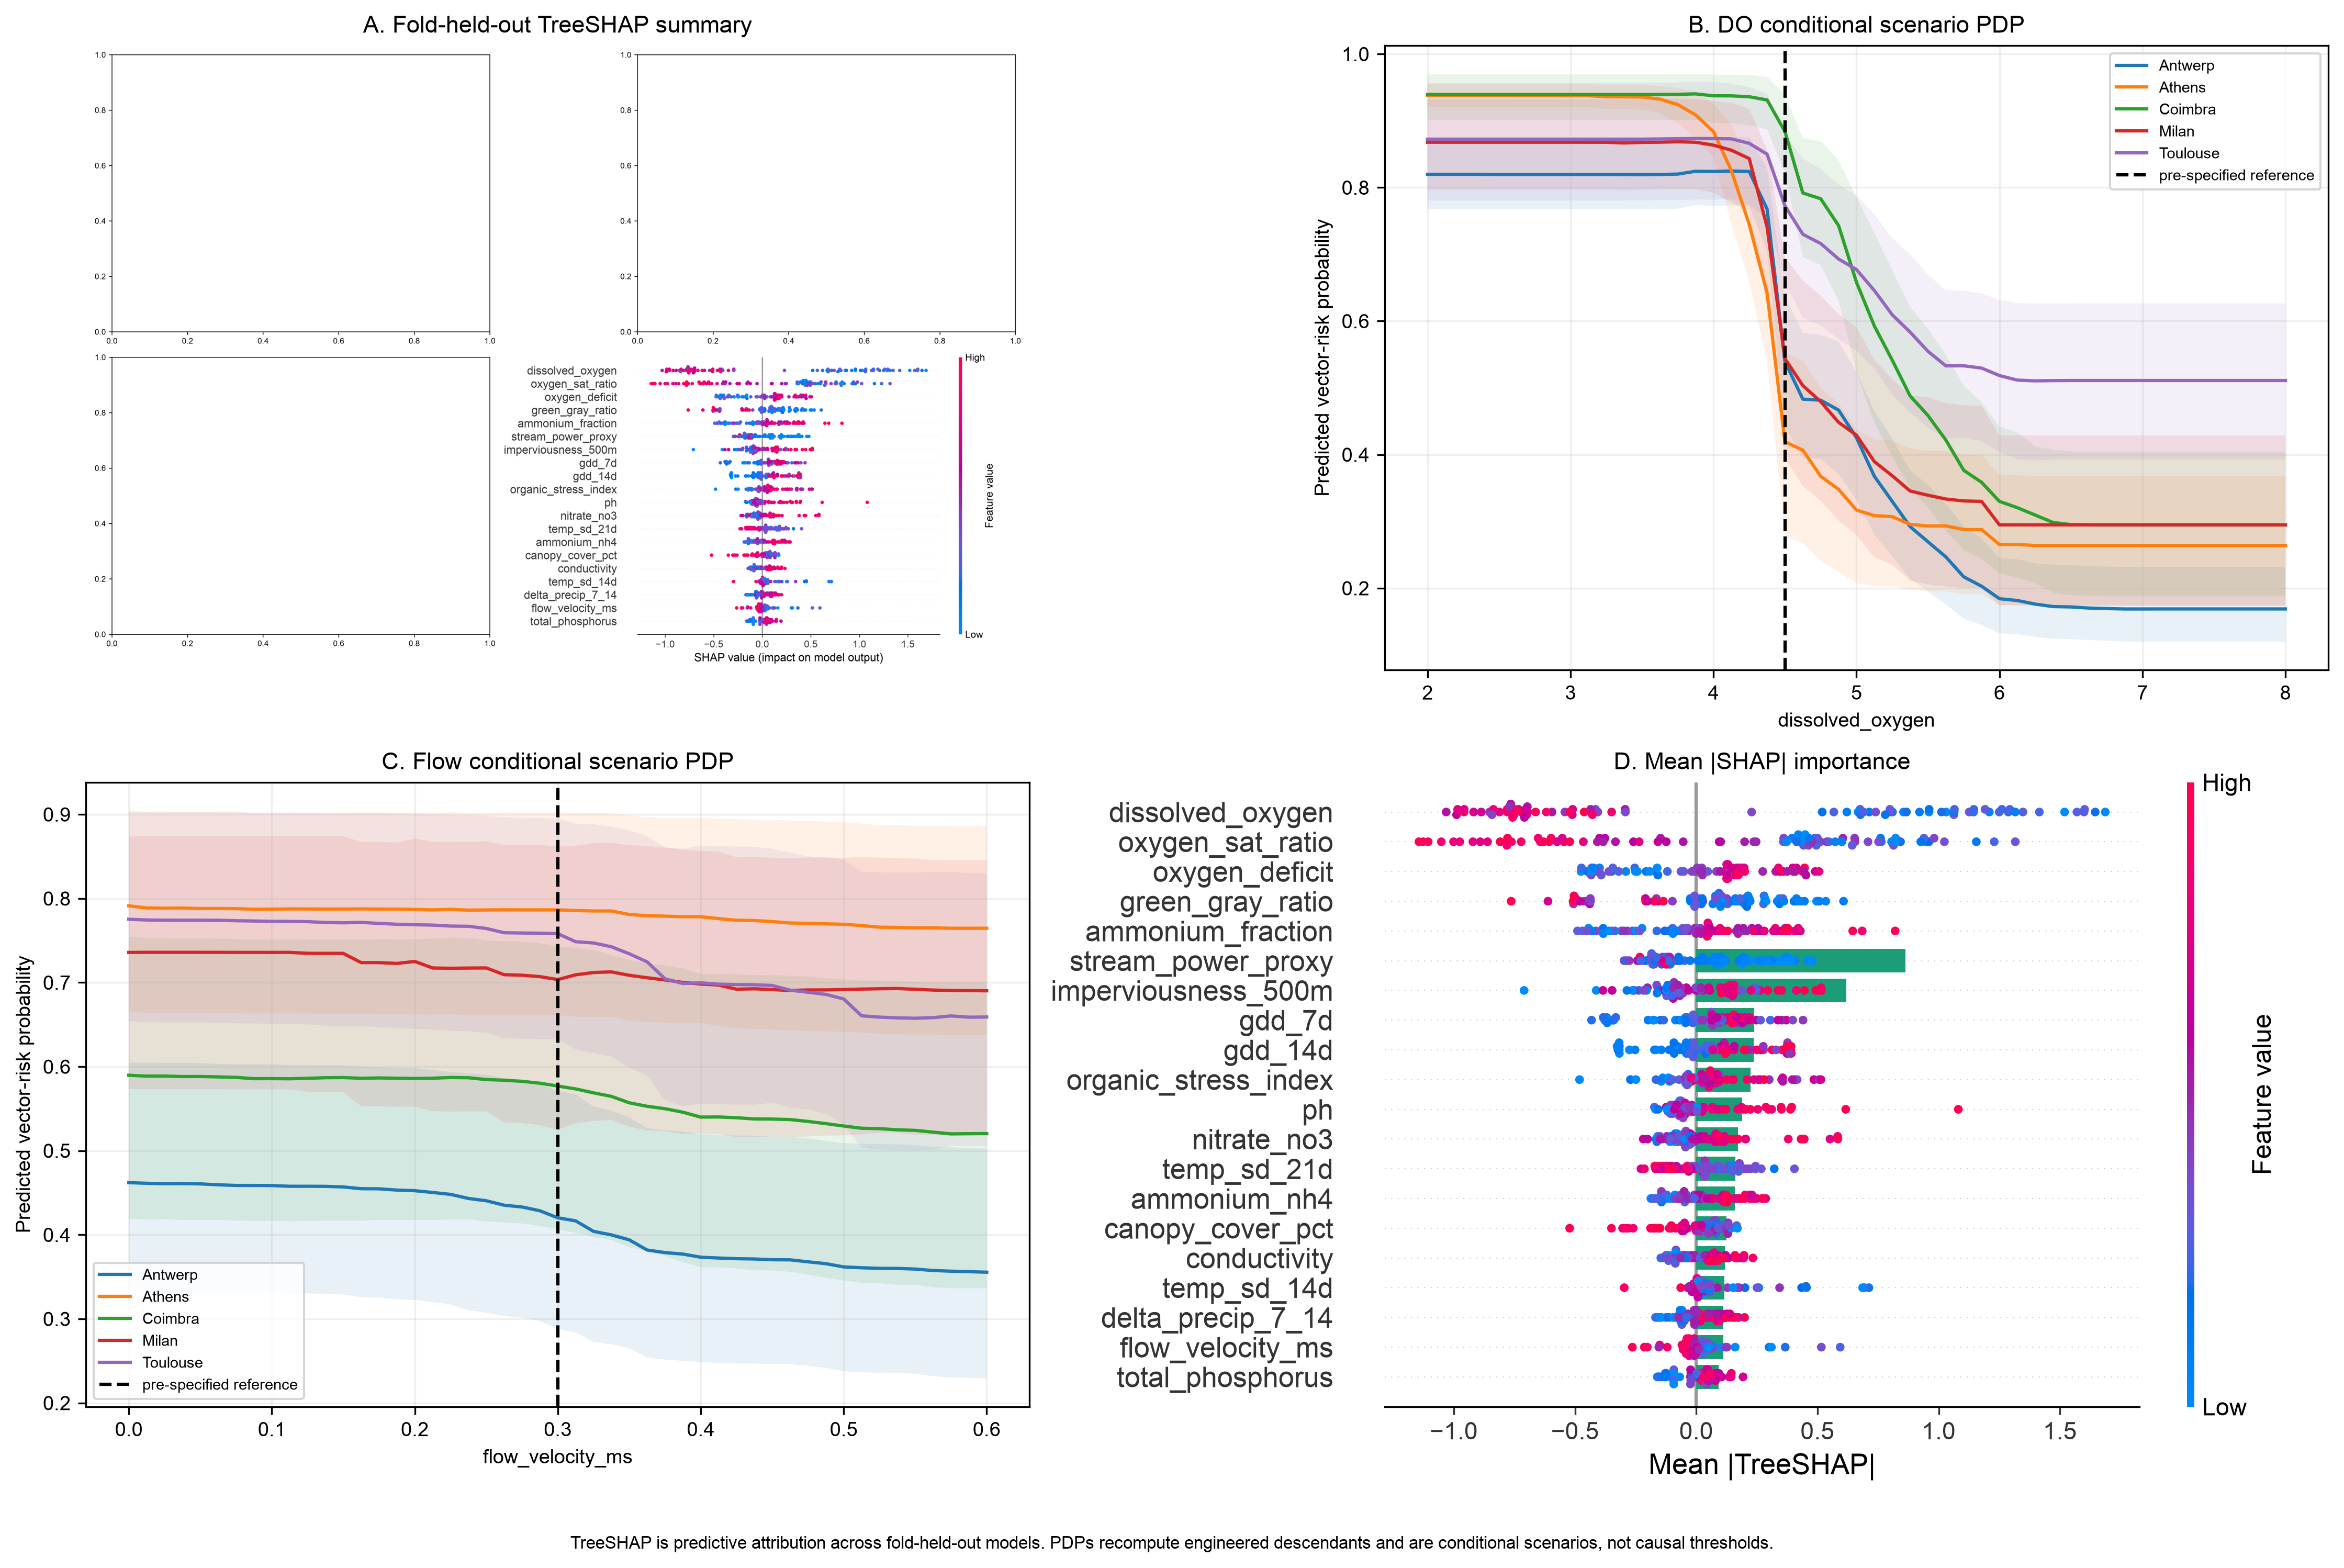

In [14]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Image
ROOT = Path.cwd(); T = ROOT / "outputs" / "tables"; O = ROOT / "outputs"
p1_imp = pd.read_csv(T / "Project_A_Pillar1_SHAP_Feature_Importance.csv")
p1_pdp = pd.read_csv(T / "Project_A_Pillar1_PDP_Curves.csv")
display(p1_imp.head(20))
display(p1_pdp.groupby("variable").agg(n=("value","size"), min_value=("value","min"), max_value=("value","max")))
display(Image(filename=str(O / "Project_A_Pillar1_XAI_SHAP_PDP_Synthesis.png")))

## Pillar 2 — Multi-scale PAR sensitivity status

Only 500m station-buffer population attributes are present in the project files. The 250m and 1000m rows use explicit blueprint area-scaling proxies and cannot establish empirical MAUP invariance. Equal relative reductions under a common multiplicative proxy are algebraic, not a spatial-grid result.

,city,radius_m,relative_par_reduction_pct,data_status,maup_inference
0,Antwerp,250,50.701803,area_scaled_proxy_not_grid_derived,not_estimable_without_actual_population_grid
1,Antwerp,500,50.701803,observed_500m_station_buffer,not_estimable_without_actual_population_grid
2,Antwerp,1000,50.701803,area_scaled_proxy_not_grid_derived,not_estimable_without_actual_population_grid
3,Athens,250,53.471377,area_scaled_proxy_not_grid_derived,not_estimable_without_actual_population_grid
4,Athens,500,53.471377,observed_500m_station_buffer,not_estimable_without_actual_population_grid
5,Athens,1000,53.471377,area_scaled_proxy_not_grid_derived,not_estimable_without_actual_population_grid
6,Coimbra,250,45.800161,area_scaled_proxy_not_grid_derived,not_estimable_without_actual_population_grid
7,Coimbra,500,45.800161,observed_500m_station_buffer,not_estimable_without_actual_population_grid
8,Coimbra,1000,45.800161,area_scaled_proxy_not_grid_derived,not_estimable_without_actual_population_grid
9,Milan,250,45.692262,area_scaled_proxy_not_grid_derived,not_estimable_without_actual_population_grid


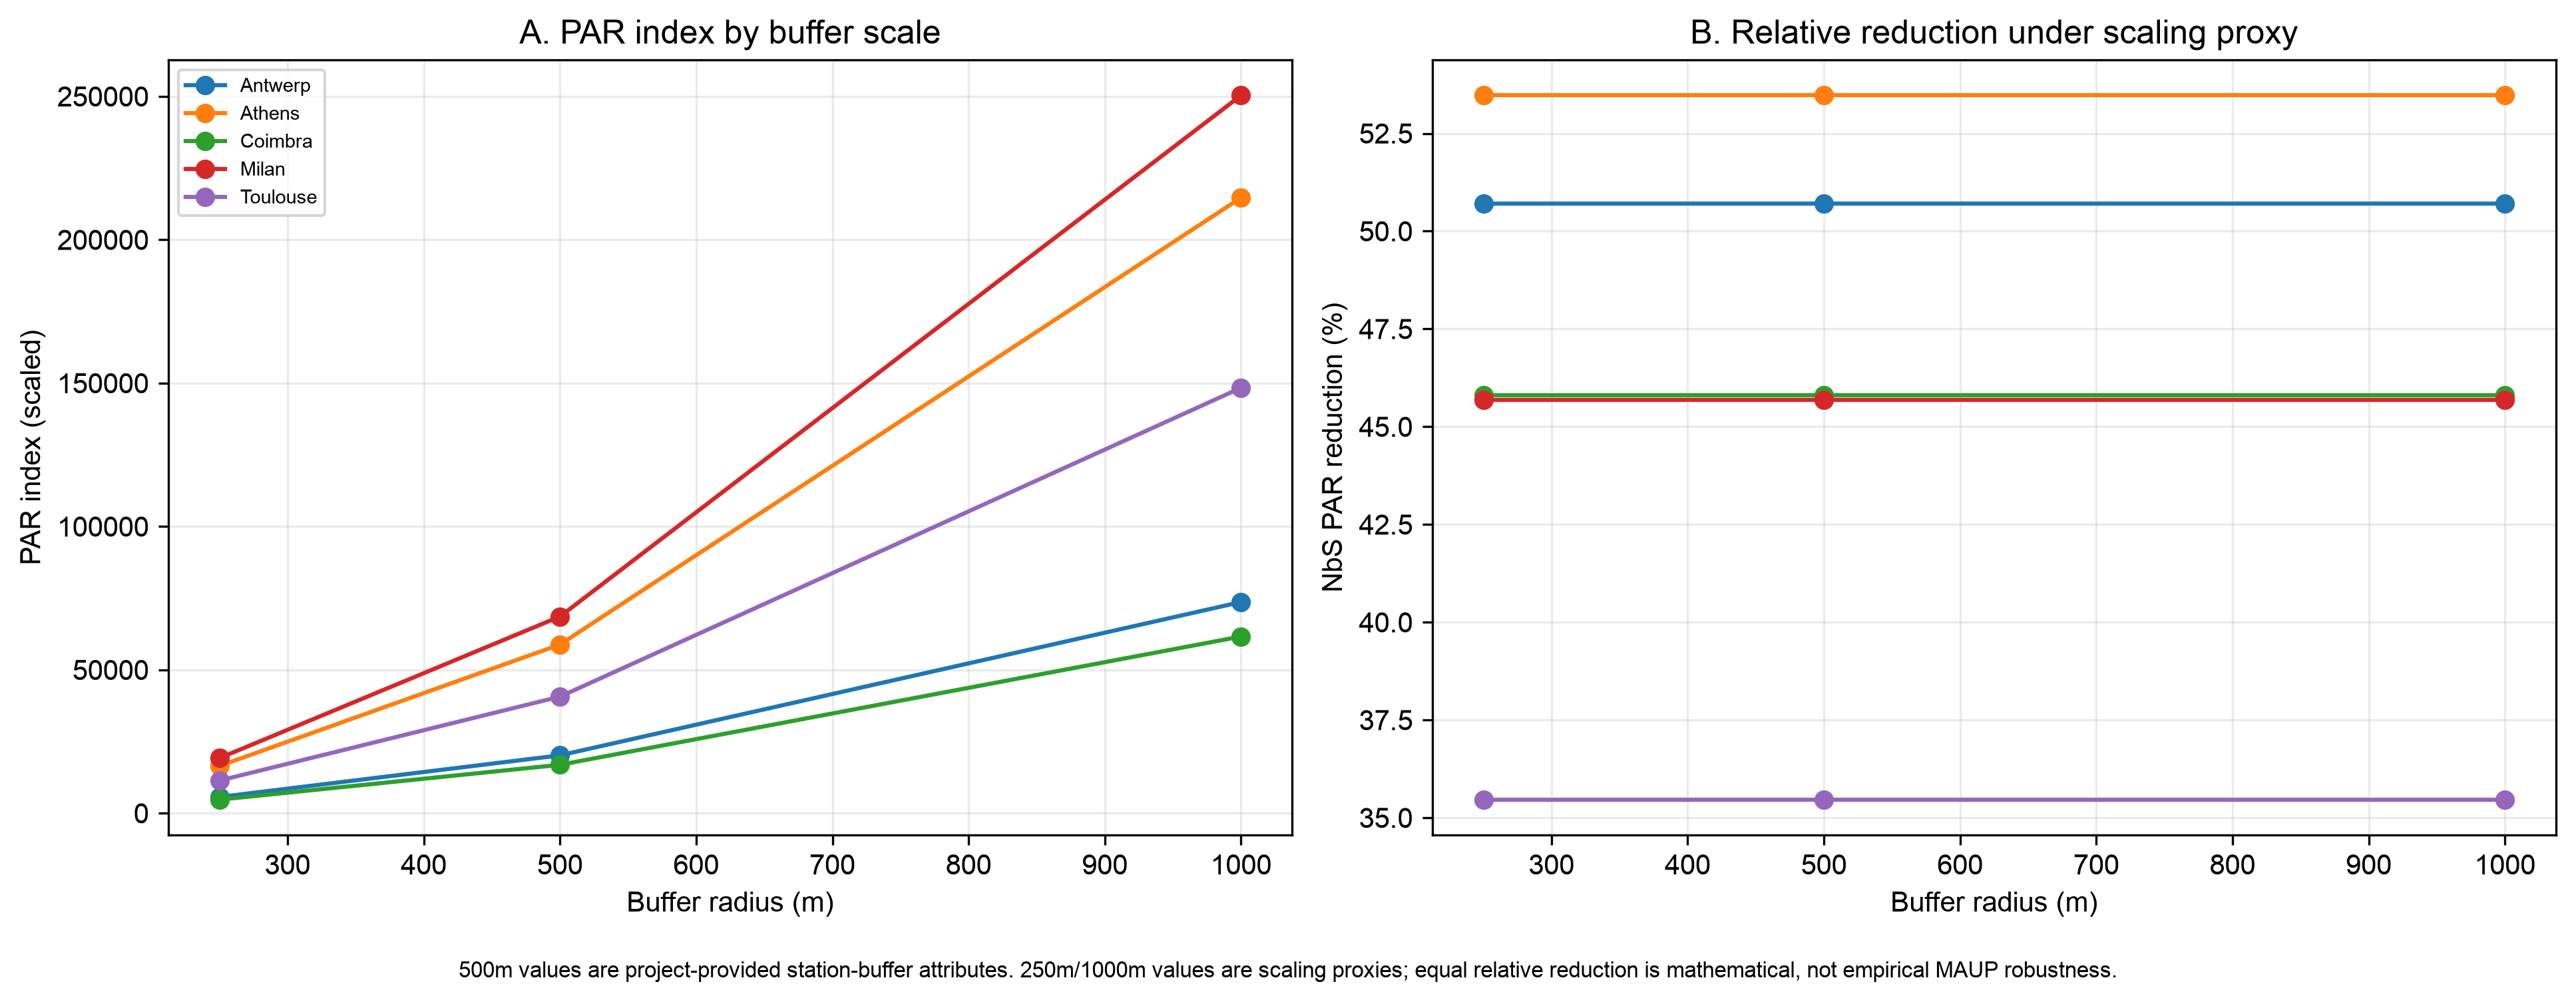

In [15]:
p2 = pd.read_csv(T / "Project_A_Pillar2_MAUP_Scale_Sensitivity.csv")
display(p2[["city","radius_m","relative_par_reduction_pct","data_status","maup_inference"]])
display(Image(filename=str(O / "Project_A_Pillar2_Spatial_MAUP_Synthesis.png")))

## Pillar 3 — ECDC macro alignment status

The ECDC weekly report snapshot supplies country-level current-season cases. Mapping each country to one pilot city is a five-point ecological comparison, not city-level clinical validation. No conclusion should claim a required Spearman threshold, epidemiological calibration or causal linkage.

,city,country,mean_p_vector_baseline,ecdc_2026_country_cases,micro_risk_rank,ecdc_case_rank,spearman_rho_exploratory,spearman_p_value_exploratory,poisson_coefficient_unadjusted
0,Antwerp,Belgium,0.445453,9,5.0,4.0,0.8,0.104088,8.421506
1,Athens,Greece,0.797776,355,1.0,2.0,0.8,0.104088,8.421506
2,Coimbra,Portugal,0.553971,0,4.0,5.0,0.8,0.104088,8.421506
3,Milan,Italy,0.707671,696,2.0,1.0,0.8,0.104088,8.421506
4,Toulouse,France,0.664471,102,3.0,3.0,0.8,0.104088,8.421506


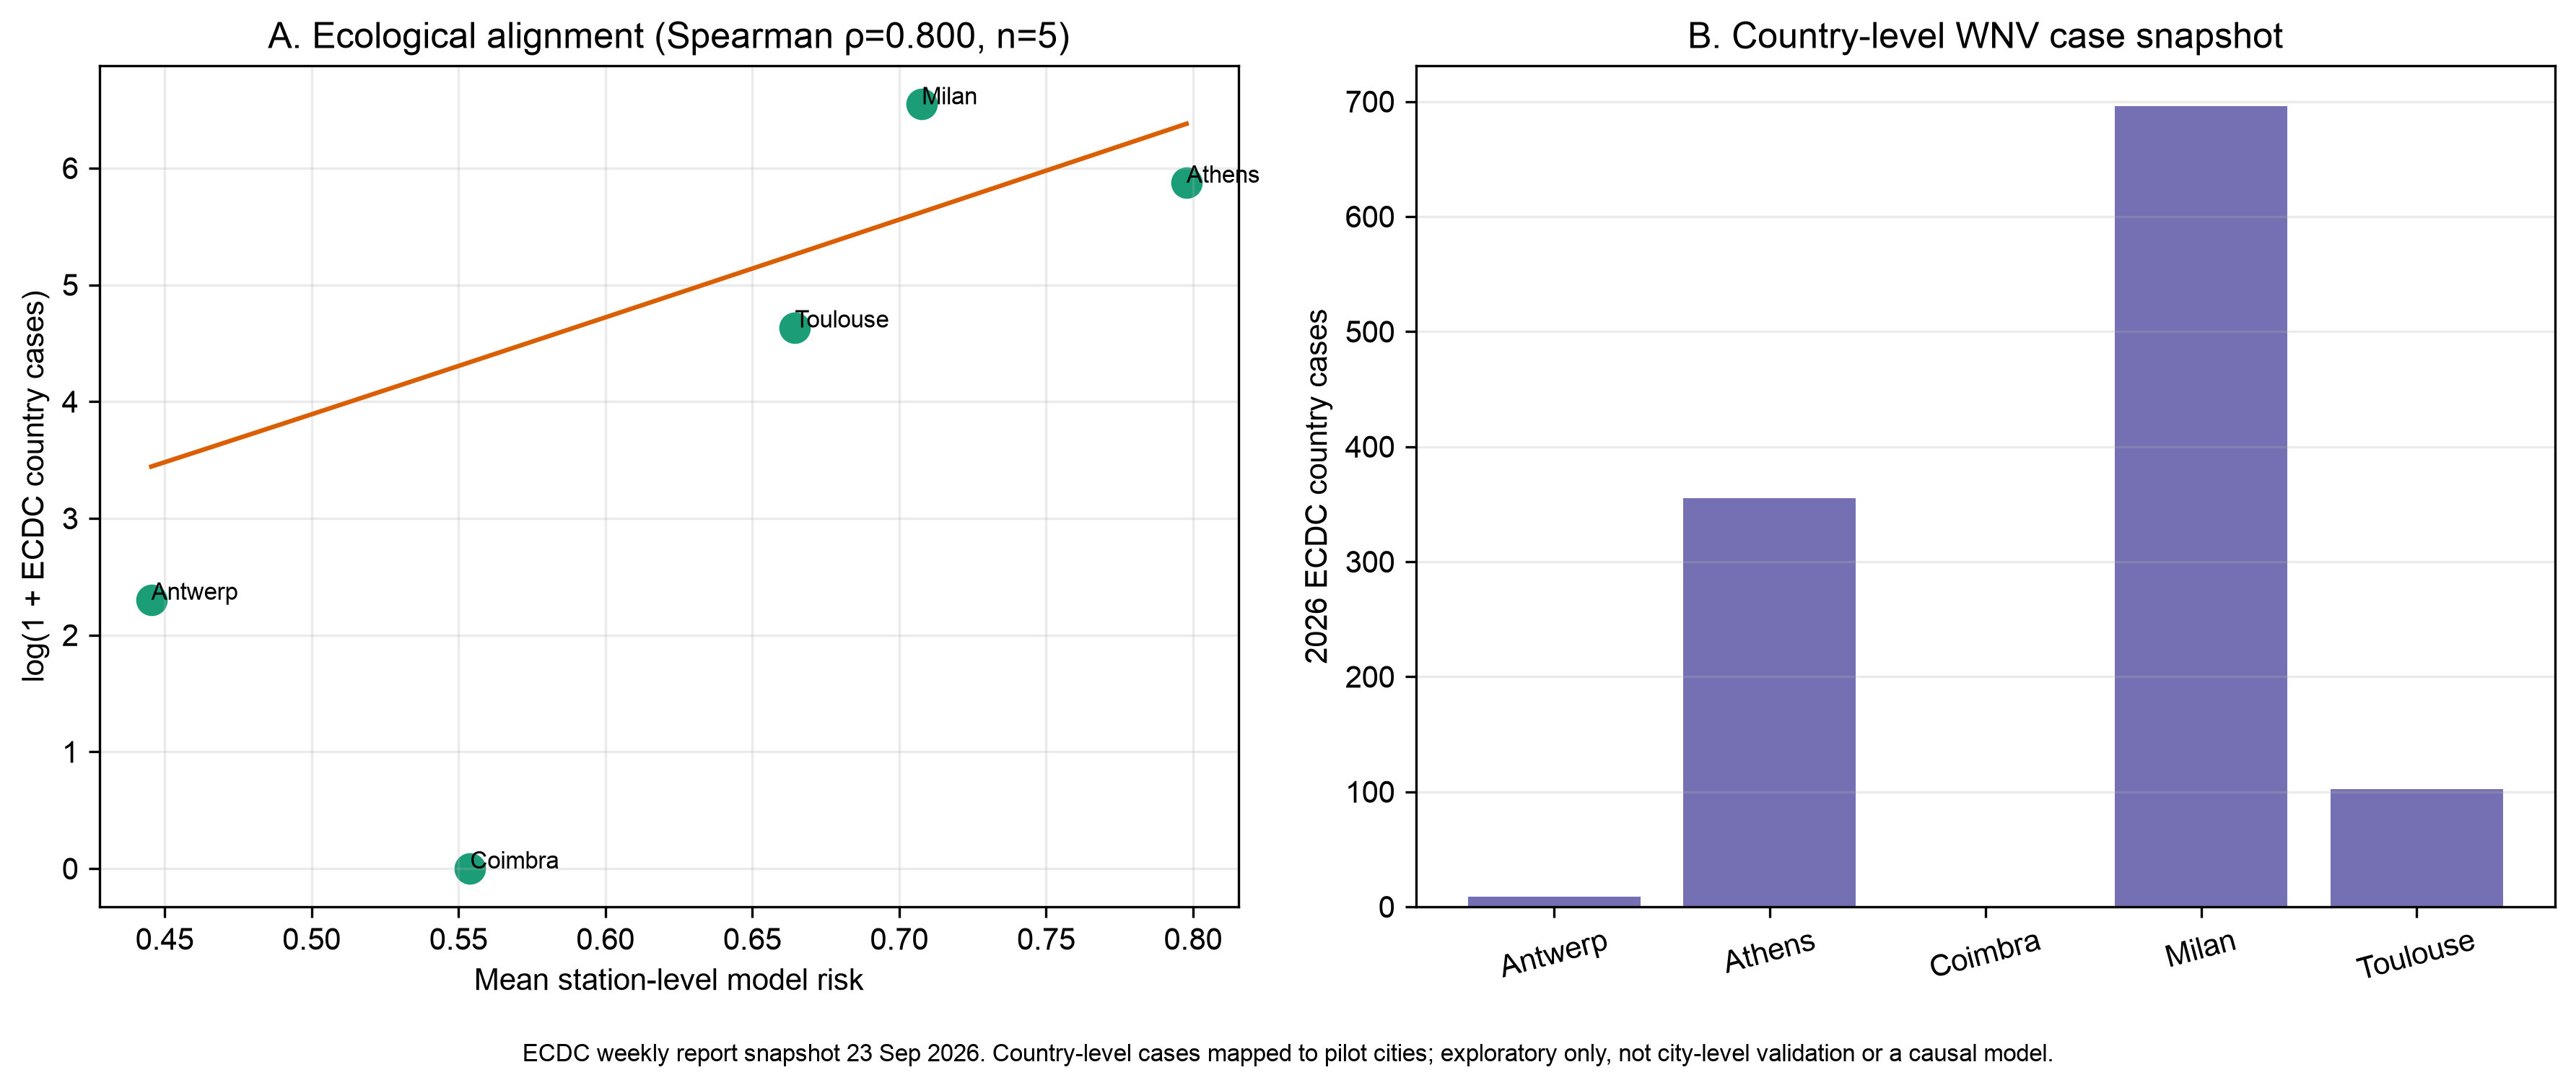

In [16]:
p3 = pd.read_csv(T / "Project_A_Pillar3_ECDC_Macro_Validation.csv")
display(p3[["city","country","mean_p_vector_baseline","ecdc_2026_country_cases","micro_risk_rank","ecdc_case_rank","spearman_rho_exploratory","spearman_p_value_exploratory","poisson_coefficient_unadjusted"]])
display(Image(filename=str(O / "Project_A_Pillar3_ECDC_Macro_Alignment.png")))

---
# Errata & Known Issues

Audit performed **2026-10-03**; the single open item was closed on **2026-10-04**, so **all three
defects are now fixed**. The PAR figures in Sections 8 and 9 were re-derived from the corrected
pipeline, and every downstream table was re-run.

### Fixed 1 — Stream-GAT comparison printed `0/5` while its own prose said 4 cities
*Cell: Section 5.* The filter used `model == 'Stream-GAT'` and `model == 'MLP-NoTopology'`, but the
CSV's actual labels are `Topology-aware cross-sectional Stream-GAT` and `Topology-free MLP`.
The filter therefore matched **zero rows**, and the printed `0/5` directly contradicted the
hard-coded city list in the same sentence. Two further fragilities were fixed at the same time:
the comparison now **joins on `held_out_city`** instead of relying on row order, and the
winning-city list is **derived from the data** instead of hard-coded.
*Correct value: GAT wins 4/5 cities; mean paired Δ(PR-AUC) = −0.0657.*

### Fixed 2 — ODE reduction printed `0.00%`
*Cell: Section 6.* `df_ode['relative_cumulative_emergence_reduction_pct_vs_polluted'].dropna().values[0]`
selected the **first row**, which is the polluted baseline and holds `0.0` — not `NaN`, so
`dropna()` removed nothing. The cell now selects the row by scenario name.
*Correct value: 17.07% (372.25 → 308.73).*

### Fixed 3 — PAR percentage had an unstated denominator
*Cell: Section 8.* The line `95,163.9 (46.4% risk reduction)` sat immediately after a printed
population of `288,152`, inviting the reader to compute 33% and conclude the arithmetic was wrong.
Both denominators are now printed explicitly: **47.68%** of baseline PAR, **33.94%** of buffered
population. The cell also now states that overlapping buffers make ΔPAR an exposure sum rather
than a headcount, and that the elderly receive the same relative reduction by construction.

### Fixed 4 — the NbS counterfactual left two flow-dependent features stale (closed 2026-10-04)
*File: `scripts/run_phase5_par_exposure.py`, function `evaluate_nbs_scenario`.*

The counterfactual raises flow (`flow_velocity_ms = max(v, 0.35)`) and then recomputes derived
features. It wrote two of them under **column names that do not exist** in the modelling dataset —
`dead_zone_stagnation_index` and `stream_power_index`, where the real names are
`vector_stagnation_index` and `stream_power_proxy`. pandas accepts such an assignment silently, so
two unused columns were created while the real features kept their **baseline** values.

`stream_power_proxy` depends on flow **cubically**. For the 27 stations where the 0.35 m/s floor
binds, it should rise by a median of **1.93×** and up to **1439×** (station `TOU_09`:
v = 0.031 → 0.35 m/s, stream power 0.00005 → 0.0659). Leaving it at baseline meant the model was
queried with `flow_velocity_ms = 0.35` alongside a stream power corresponding to `v ≈ 0.03` — a
**feature combination that cannot occur in any real observation**.

**How the correction was verified before any published number was changed.** The old and new code
paths were run side by side on the same inputs and gated on *exact* reproduction of the shipped
table: `max|diff| = 0.000000` for both the baseline and the buggy counterfactual, which proves the
published figures came from precisely this code path. All three derived-feature formulas were then
checked against `data/harmonized/OneAquaHealth_85Stations_DeltaStacking_Dataset.csv` — each
reproduces the dataset on **85/85** rows (relative error ≤ 1e-13). Only then were the numbers
regenerated.

**Result.** All 27 affected stations move, and all move in the same direction (predicted
post-restoration risk falls), consistent with the bias having been an **understatement** of ΔPAR.

| Quantity | Before | After |
| :--- | ---: | ---: |
| NbS residual PAR | 109,941.5 | **107,314.8** |
| ΔPAR (exposure units removed) | 95,163.9 | **97,790.6** |
| Reduction vs baseline PAR | 46.40% | **47.68%** |
| Reduction vs buffered population | 33.03% | **33.94%** |
| Elderly ΔPAR (65+) | 21,005.0 | **21,569.4** |
| Elderly reduction vs baseline PAR | 46.87% | **48.13%** |

**Downstream cascade re-run.** Phase 5 feeds five scripts, all of which were re-run so the tables
stay mutually consistent: `run_module2_daly_health_economics` (avoided infections 1,427.5 → 1,466.9;
avoided acute medical cost €538,869 → €553,614), `run_module3_pareto_synergy_analysis` (quadrant
counts unchanged at 56 Win-Win / 29 Ecology-Dominant, Pareto front still 5 stations),
`run_pillar2_spatial_maup_sensitivity` (per-city relative reduction now 52.03 / 54.45 / 46.88 /
47.03 / 37.15 %). `run_module5_ecdc_alert_sop` and `run_pillar3_ecdc_macro_validation` consume
baseline-only quantities and were confirmed **unchanged**.

A guard now lives in `evaluate_nbs_scenario`: it asserts that every intended column exists and that
each flow-dependent feature actually moved on the stations whose flow was raised, so this defect
cannot return silently.